# Testing of Sequentially Trained Models

**Objectives:**
1. Load the final model weights (Transformer+OC-SVM, PRAE, PNN) trained in notebook 1.
2. Evaluate on the held-out **Test Day (Day 25)**.
3. Split the trading day into meaningful time periods (1st hour, rest of morning, afternoon, American open, after-market close).
4. Classify anomalies:
    - Transformer + OC-SVM: OC-SVM decision function.
    - PNN: Spoofing gain.
    - PRAE: Rolling False Discovery Rate (RFDR) on the reconstruction error ($\mu$ is unavailable for a test set).
5. Visualize anomaly scores and detections across time periods.
6. Perform **Root Cause Analysis** -- identify features contributing most to top anomalies.

In [1]:
import os, sys, math, logging, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import joblib
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences, load_processed
from detection.data.preprocessing import get_time_frac, assign_period
from detection.models import hybrid, pnn, prae
from detection.models.transformer import BottleneckTransformer
from detection.spoofing.gain import compute_spoofing_gains_batch
from detection.thresholds.rfdr import RollingFalseDiscoveryRate
from detection.trainers.factory import load_model

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## Configuration

In [ ]:
DATA_DIR = os.path.join("..", "data", "processed", "TOTF.PA-book")
RESULTS_DIR = os.path.join("..", "results")
OUTPUT_DIR = os.path.join("..", "results", "test_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_TYPES = ["transformer_ocsvm", "pnn", "prae"]

# Hyperparameters (must match training notebook)
SEQ_LENGTH = 25
BATCH_SIZE = 64
WARMUP_STEPS = 3000

# LOB columns present in processed files (not features)
LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [("bid","price"),("bid","volume"),("ask","price"),("ask","volume")]
]

# RFDR threshold params (used only for PRAE)
RFDR_WINDOW = 500
RFDR_ALPHA = 0.05

# Spoofing gain params (used only for PNN)
SPOOF_Q = 4500         # spoof order size
SPOOF_q = 100          # genuine order size
SPOOF_DELTA_A = 0.0    # ask order at best ask
SPOOF_DELTA_B = 0.01   # spoof bid close to best bid
SPOOF_FEES = {"maker": 0.0, "taker": 0.05}

# Test files
FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
TEST_FILES = [FILES[22], FILES[23], FILES[24], FILES[25], FILES[26]]
print(f"Available files: {len(FILES)}")
for i, f in enumerate(TEST_FILES):
    print(f"Test file {i+1}: {os.path.basename(f)}")

# Time-of-day periods for Euronext Paris (in hours since midnight, CET)
PERIODS = {
    "1st_hour":       (9.0,  10.0),
    "rest_of_morning":(10.0, 12.0),
    "afternoon":      (12.0, 15.5),
    "american_open":  (15.5, 17.5),
    "aftermarket":    (17.5, 24.0),
}
print("Periods:", {k: f"{v[0]:.1f}h-{v[1]:.1f}h" for k, v in PERIODS.items()})

# Check whether pre-computed results already exist (from test.py or a previous run)
_saved_meta_path = os.path.join(OUTPUT_DIR, "test_meta.json")
SAVED_RESULTS_AVAILABLE = (
    os.path.exists(_saved_meta_path)
    and all(
        os.path.exists(os.path.join(OUTPUT_DIR, f"{mt}_scores.npy"))
        for mt in MODEL_TYPES
    )
)
if SAVED_RESULTS_AVAILABLE:
    with open(_saved_meta_path) as _f:
        _saved_meta = json.load(_f)
    _saved_files = set(_saved_meta.get("test_files", []))
    _current_files = {os.path.basename(f) for f in TEST_FILES}
    SAVED_RESULTS_AVAILABLE = _saved_files == _current_files
    if SAVED_RESULTS_AVAILABLE:
        print(f"\nPre-computed results found in {OUTPUT_DIR} (matching test files). Will load them.")
    else:
        print(f"\nPre-computed results exist but test files differ. Will recompute.")
else:
    print(f"\nNo pre-computed results found. Will compute from scratch.")

## Load Feature Names

In [3]:
feature_names_map = {}
for mt in MODEL_TYPES:
    feat_path = os.path.join(RESULTS_DIR, f"{mt}_features.txt")
    if os.path.exists(feat_path):
        with open(feat_path) as f:
            feature_names_map[mt] = [line.strip() for line in f if line.strip()]
    else:
        _, _feat_tmp = load_processed(TEST_FILES[0], "xltime", LOB_COLUMNS)
        feature_names_map[mt] = _feat_tmp.columns.tolist()
        del _feat_tmp

print(f"Feature names loaded for {len(feature_names_map)} models")
for mt, fnames in feature_names_map.items():
    print(f"  {mt}: {len(fnames)} features")


Feature names loaded for 3 models
  transformer_ocsvm: 89 features
  pnn: 89 features
  prae: 89 features


## Score Test Days with Each Model

For each test file, load the raw LOB data, compute features, and score with all three models.

- **Transformer + OC-SVM**: OC-SVM decision function (distance to hyperplane); anomaly if outside the boundary.
- **PNN**: Spoofing gain (expected cost reduction from a hypothetical spoof order); anomaly if gain > 0.
- **PRAE**: Rolling False Discovery Rate (RFDR) on reconstruction error ($\mu$ unavailable at test time).

In [ ]:
if SAVED_RESULTS_AVAILABLE:
    # ── Load pre-computed results ──────────────────────────────────
    logger.info("Loading pre-computed results from %s", OUTPUT_DIR)
    with open(os.path.join(OUTPUT_DIR, "test_meta.json")) as f:
        saved_meta = json.load(f)

    day_names = saved_meta["day_names"]
    day_boundaries = saved_meta["day_boundaries"]

    all_scores = {}
    all_preds = {}
    for mt in MODEL_TYPES:
        all_scores[mt] = np.load(os.path.join(OUTPUT_DIR, f"{mt}_scores.npy"))
        all_preds[mt] = np.load(os.path.join(OUTPUT_DIR, f"{mt}_preds.npy"))
        logger.info("  %s: %d scores, %d anomalies (%.2f%%)",
                     mt, len(all_scores[mt]), all_preds[mt].sum(),
                     100 * all_preds[mt].mean())

    period_labels_seq = np.load(os.path.join(OUTPUT_DIR, "period_labels.npy"), allow_pickle=True)
    all_thresholds = {mt: 0.0 for mt in MODEL_TYPES}

    # Rebuild feat_values_seq from the test files (needed for root cause analysis / viz)
    all_feat_values_seq = []
    for test_file in TEST_FILES:
        _, features_day = load_processed(test_file, "xltime", LOB_COLUMNS)
        n_seq_day = len(features_day) - SEQ_LENGTH
        feat_values_day_seq = features_day.iloc[SEQ_LENGTH: SEQ_LENGTH + n_seq_day].reset_index(drop=True)
        all_feat_values_seq.append(feat_values_day_seq)
    feat_values_seq = pd.concat(all_feat_values_seq, ignore_index=True)

    total_samples = len(next(iter(all_scores.values())))
    logger.info("Loaded %d total samples across %d test files.", total_samples, len(TEST_FILES))

else:
    # ── Compute from scratch ──────────────────────────────────────
    loaded_models = {}
    loaded_scalers = {}

    for model_type in MODEL_TYPES:
        feat_names = feature_names_map[model_type]
        num_features = len(feat_names)
        weights_path = os.path.join(RESULTS_DIR, f"{model_type}_weights.pth")
        model, ocsvm = load_model(model_type, num_features, weights_path, DEVICE, SEQ_LENGTH)
        loaded_models[model_type] = (model, ocsvm)

        scaler_path = os.path.join(RESULTS_DIR, f"{model_type}_scaler.pkl")
        loaded_scalers[model_type] = joblib.load(scaler_path) if os.path.exists(scaler_path) else MinMaxScaler()
        logger.info("Loaded model & scaler for %s (%d features)", model_type, num_features)

    all_scores = {mt: [] for mt in MODEL_TYPES}
    all_preds = {mt: [] for mt in MODEL_TYPES}
    all_thresholds = {mt: 0.0 for mt in MODEL_TYPES}
    all_period_labels_seq = []
    all_feat_values_seq = []
    day_boundaries = [0]
    day_names = []

    for file_idx, test_file in enumerate(TEST_FILES):
        day_name = os.path.basename(test_file)
        day_names.append(day_name)
        logger.info("=" * 70)
        logger.info("Test file %d/%d: %s", file_idx + 1, len(TEST_FILES), day_name)

        df_day, features_day = load_processed(test_file, "xltime", LOB_COLUMNS)

        time_frac_day = get_time_frac(df_day)[:len(features_day)]
        period_labels_day = assign_period(time_frac_day, PERIODS)

        spread_raw_day = (df_day["ask-price-1"] - df_day["bid-price-1"]).values

        n_seq_day = len(features_day) - SEQ_LENGTH

        period_labels_day_seq = period_labels_day[SEQ_LENGTH: SEQ_LENGTH + n_seq_day]
        all_period_labels_seq.append(period_labels_day_seq)

        feat_values_day_seq = features_day.iloc[SEQ_LENGTH: SEQ_LENGTH + n_seq_day].reset_index(drop=True)
        all_feat_values_seq.append(feat_values_day_seq)

        logger.info("Day rows (after warmup): %d to %d sequences", len(features_day), n_seq_day)

        for model_type in MODEL_TYPES:
            feat_names = feature_names_map[model_type]
            scaler = loaded_scalers[model_type]
            model, ocsvm = loaded_models[model_type]

            feat_df = features_day.copy()
            for col in feat_names:
                if col not in feat_df.columns:
                    feat_df[col] = 0.0
            feat_df = feat_df[feat_names]

            scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
            sequences = create_sequences(scaled, SEQ_LENGTH)
            num_features = len(feat_names)

            if model_type == "transformer_ocsvm":
                x_tensor = torch.tensor(sequences, dtype=torch.float32)
                ds = TensorDataset(x_tensor, x_tensor)
                loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
                if ocsvm is not None:
                    detector = hybrid.TransformerOCSVM.__new__(hybrid.TransformerOCSVM)
                    detector.transformer = model
                    detector.ocsvm = ocsvm
                    scores = detector.predict(loader)
                else:
                    scores_list = []
                    model.eval()
                    with torch.no_grad():
                        for batch in loader:
                            x = batch[0].to(DEVICE)
                            rec = model(x)
                            err = torch.mean((x - rec) ** 2, dim=(1, 2)).cpu().numpy()
                            scores_list.append(err)
                    scores = np.concatenate(scores_list)
                del x_tensor, ds, loader
                preds = (scores > 0).astype(int)
                threshold_val = 0.0

            elif model_type == "pnn":
                target_col = "log_return"
                target_idx = feat_names.index(target_col) if target_col in feat_names else 0

                all_mu, all_sigma, all_alpha = [], [], []
                n_seqs = len(sequences)

                model.eval()
                with torch.no_grad():
                    for start in range(0, n_seqs, BATCH_SIZE):
                        end = min(start + BATCH_SIZE, n_seqs)
                        x_batch = torch.tensor(
                            np.ascontiguousarray(sequences[start:end]),
                            dtype=torch.float32,
                        ).reshape(end - start, -1).to(DEVICE)
                        mu, sigma, alpha = model(x_batch)
                        all_mu.append(mu.cpu().numpy().flatten())
                        all_sigma.append(sigma.cpu().numpy().flatten())
                        all_alpha.append(alpha.cpu().numpy().flatten())

                mu_arr = np.concatenate(all_mu)
                sigma_arr = np.concatenate(all_sigma)
                alpha_arr = np.concatenate(all_alpha)

                spread_seq = spread_raw_day[SEQ_LENGTH: SEQ_LENGTH + len(mu_arr)]
                if len(spread_seq) < len(mu_arr):
                    spread_seq = np.pad(spread_seq, (0, len(mu_arr) - len(spread_seq)), mode="edge")
                spread_seq = np.abs(spread_seq)
                spread_seq = np.where(spread_seq > 0, spread_seq, 1e-4)

                spoofing_gains = compute_spoofing_gains_batch(
                    mu_arr, sigma_arr, alpha_arr, spread_seq,
                    delta_a=SPOOF_DELTA_A, delta_b=SPOOF_DELTA_B,
                    Q=SPOOF_Q, q=SPOOF_q,
                    fees=SPOOF_FEES, side="ask",
                )

                scores = spoofing_gains
                preds = (scores > 0).astype(int)
                threshold_val = 0.0

            elif model_type == "prae":
                x_tensor = torch.tensor(sequences, dtype=torch.float32)
                ds = TensorDataset(x_tensor, x_tensor)
                loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
                scores_list = []
                model.eval()
                with torch.no_grad():
                    for batch in loader:
                        x = batch[0].to(DEVICE)
                        rec, _ = model(x, training=False)
                        err = torch.sum((x - rec) ** 2, dim=tuple(range(1, x.dim()))).cpu().numpy()
                        scores_list.append(err)
                scores = np.concatenate(scores_list)
                del x_tensor, ds, loader

                rfdr = RollingFalseDiscoveryRate(window_size=RFDR_WINDOW, alpha=RFDR_ALPHA)
                preds = np.zeros(len(scores), dtype=int)
                threshold_val = 0.0
                for i, s in enumerate(scores):
                    is_anom, threshold_val = rfdr.process_new_score(float(s))
                    preds[i] = int(is_anom)

            all_scores[model_type].append(scores)
            all_preds[model_type].append(preds)
            all_thresholds[model_type] = threshold_val

            logger.info("  %s: %d anomalies / %d samples (%.2f%%)",
                        model_type, preds.sum(), len(preds), 100 * preds.mean())

        day_boundaries.append(day_boundaries[-1] + n_seq_day)

    for mt in MODEL_TYPES:
        all_scores[mt] = np.concatenate(all_scores[mt])
        all_preds[mt] = np.concatenate(all_preds[mt])

    period_labels_seq = np.concatenate(all_period_labels_seq)
    feat_values_seq = pd.concat(all_feat_values_seq, ignore_index=True)

    total_samples = len(next(iter(all_scores.values())))
    print(f"\nScoring complete: {total_samples} total samples across {len(TEST_FILES)} test file(s).")
    for mt in MODEL_TYPES:
        n_anom = all_preds[mt].sum()
        print(f"  {mt}: {n_anom} anomalies ({100*n_anom/total_samples:.2f}%)")

    # ── Save results to OUTPUT_DIR ────────────────────────────────
    logger.info("Saving results to %s", OUTPUT_DIR)
    for mt in MODEL_TYPES:
        np.save(os.path.join(OUTPUT_DIR, f"{mt}_scores.npy"), all_scores[mt])
        np.save(os.path.join(OUTPUT_DIR, f"{mt}_preds.npy"), all_preds[mt])
    np.save(os.path.join(OUTPUT_DIR, "period_labels.npy"), period_labels_seq)

    meta = {
        "day_names": day_names,
        "day_boundaries": day_boundaries,
        "test_files": [os.path.basename(f) for f in TEST_FILES],
        "total_samples": total_samples,
        "seq_length": SEQ_LENGTH,
        "batch_size": BATCH_SIZE,
        "rfdr_window": RFDR_WINDOW,
        "rfdr_alpha": RFDR_ALPHA,
        "spoof_Q": SPOOF_Q,
        "spoof_q": SPOOF_q,
    }
    with open(os.path.join(OUTPUT_DIR, "test_meta.json"), "w") as f:
        json.dump(meta, f, indent=2)

    # Per-period anomaly rates
    rows = []
    for mt in MODEL_TYPES:
        preds_mt = all_preds[mt]
        n = min(len(preds_mt), len(period_labels_seq))
        for period_name in PERIODS:
            mask = period_labels_seq[:n] == period_name
            total_p = mask.sum()
            if total_p == 0:
                continue
            n_anom = preds_mt[:n][mask].sum()
            rows.append({"model": mt, "period": period_name, "total": int(total_p),
                         "anomalies": int(n_anom), "rate_pct": round(100 * n_anom / total_p, 4)})
    pd.DataFrame(rows).to_csv(os.path.join(OUTPUT_DIR, "anomaly_rates_by_period.csv"), index=False)

    # Per-day summary
    day_rows = []
    for day_idx, dn in enumerate(day_names):
        lo = day_boundaries[day_idx]
        hi = day_boundaries[day_idx + 1]
        n_day = hi - lo
        for mt in MODEL_TYPES:
            day_preds = all_preds[mt][lo:hi]
            day_scores = all_scores[mt][lo:hi]
            n_anom = int(day_preds.sum())
            day_rows.append({"day": dn, "model": mt, "n_samples": n_day,
                             "n_anomalies": n_anom,
                             "rate_pct": round(100 * n_anom / n_day, 4) if n_day > 0 else 0.0,
                             "mean_score": float(day_scores.mean()),
                             "max_score": float(day_scores.max())})
    pd.DataFrame(day_rows).to_csv(os.path.join(OUTPUT_DIR, "anomaly_rates_by_day.csv"), index=False)

    # Consensus analysis
    n_total = min(len(all_preds[mt]) for mt in MODEL_TYPES)
    pred_matrix_save = np.column_stack([all_preds[mt][:n_total] for mt in MODEL_TYPES])
    n_models_flagged_save = pred_matrix_save.sum(axis=1)
    consensus_rows = []
    for n_agree in range(len(MODEL_TYPES) + 1):
        count = int((n_models_flagged_save == n_agree).sum())
        consensus_rows.append({"n_models_agreeing": n_agree, "sample_count": count,
                               "pct": round(100 * count / n_total, 4)})
    pd.DataFrame(consensus_rows).to_csv(os.path.join(OUTPUT_DIR, "consensus_agreement.csv"), index=False)

    # Root cause analysis
    rca_rows = []
    for mt in MODEL_TYPES:
        scores_mt = all_scores[mt]
        preds_mt = all_preds[mt]
        n = min(len(scores_mt), len(feat_values_seq))
        normal_mask = preds_mt[:n] == 0
        if normal_mask.sum() <= 10:
            continue
        normal_mean = feat_values_seq.iloc[:n][normal_mask].mean()
        normal_std = feat_values_seq.iloc[:n][normal_mask].std().replace(0, 1e-10)
        top_idx = int(np.argmax(scores_mt[:n]))
        top_feat = feat_values_seq.iloc[top_idx]
        z_scores = ((top_feat - normal_mean) / normal_std).abs().sort_values(ascending=False)
        for rank, (feat_name, z) in enumerate(z_scores.head(15).items(), 1):
            rca_rows.append({"model": mt, "analysis": "top_anomaly", "rank": rank,
                             "feature": feat_name, "z_score": round(float(z), 4),
                             "value": round(float(top_feat[feat_name]), 6)})
        threshold_10pct = np.percentile(scores_mt[:n], 90)
        top10_mask = scores_mt[:n] >= threshold_10pct
        top10_mean = feat_values_seq.iloc[:n][top10_mask].mean()
        diff = ((top10_mean - normal_mean) / normal_std).abs().sort_values(ascending=False)
        for rank, (feat_name, d) in enumerate(diff.head(15).items(), 1):
            rca_rows.append({"model": mt, "analysis": "top10pct_mean", "rank": rank,
                             "feature": feat_name, "z_score": round(float(d), 4),
                             "value": round(float(top10_mean[feat_name]), 6)})
    pd.DataFrame(rca_rows).to_csv(os.path.join(OUTPUT_DIR, "root_cause_analysis.csv"), index=False)

    logger.info("All results saved to %s", OUTPUT_DIR)
    for fname in sorted(os.listdir(OUTPUT_DIR)):
        fpath = os.path.join(OUTPUT_DIR, fname)
        logger.info("  %s (%.1f KB)", fname, os.path.getsize(fpath) / 1024)

## Anomaly Rates by Time Period

Anomaly rate (%) by period and model (cumulated over 5 test files):


Model,pnn,prae,transformer_ocsvm
Period,,,
1st_hour,0.05,2.73,0.21
rest_of_morning,0.04,2.59,0.16
afternoon,0.05,2.97,0.13
american_open,0.04,2.95,0.06
aftermarket,NaN,NaN,NaN


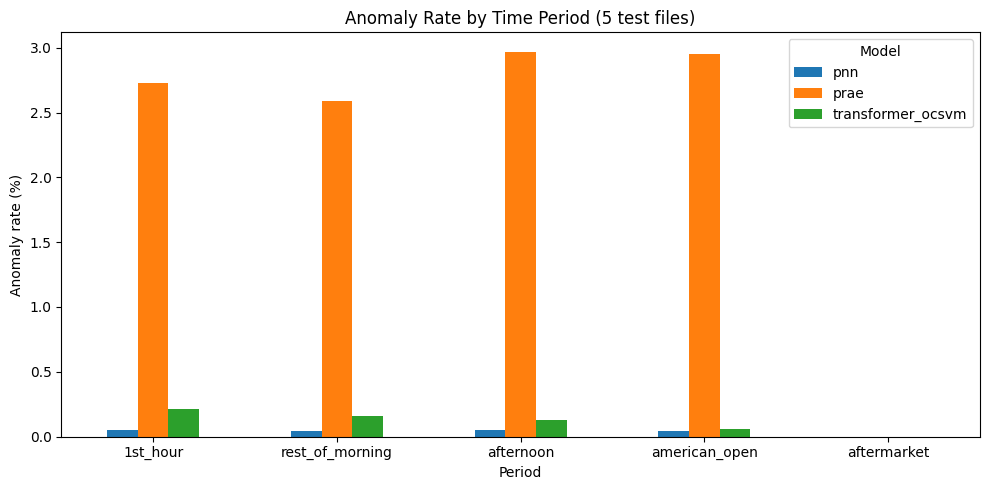

In [5]:
rows = []
for mt in MODEL_TYPES:
    preds = all_preds[mt]
    n = min(len(preds), len(period_labels_seq))
    for period_name in PERIODS:
        mask = period_labels_seq[:n] == period_name
        total = mask.sum()
        if total == 0:
            continue
        n_anom = preds[:n][mask].sum()
        rows.append({
            "Model": mt,
            "Period": period_name,
            "Total": int(total),
            "Anomalies": int(n_anom),
            "Rate (%)": round(100 * n_anom / total, 2),
        })

period_df = pd.DataFrame(rows)
pivot = period_df.pivot_table(index="Period", columns="Model", values="Rate (%)", aggfunc="first")
pivot = pivot.reindex([p for p in PERIODS])

n_days = len(TEST_FILES)
print(f"Anomaly rate (%) by period and model (cumulated over {n_days} test file{'s' if n_days > 1 else ''}):")
display(pivot)

ax = pivot.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_ylabel("Anomaly rate (%)")
ax.set_title(f"Anomaly Rate by Time Period ({n_days} test file{'s' if n_days > 1 else ''})")
ax.legend(title="Model")
plt.tight_layout()
plt.show()

## Anomaly Score Visualization

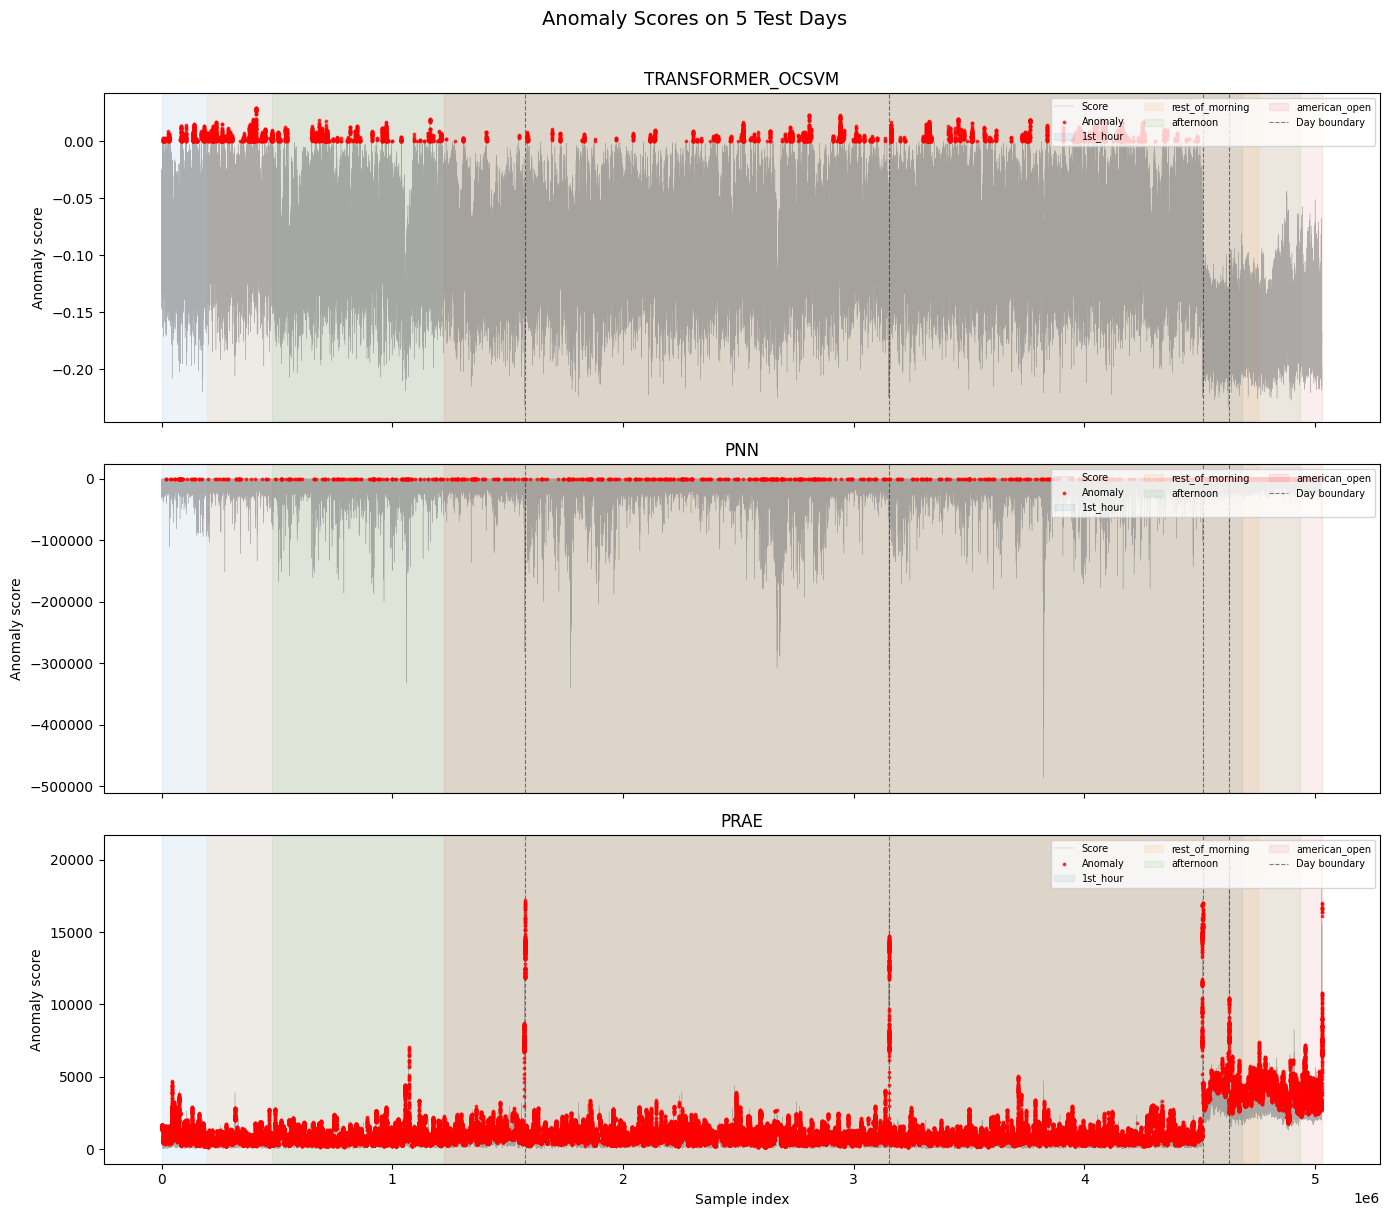

In [6]:
fig, axes = plt.subplots(len(MODEL_TYPES), 1, figsize=(14, 4 * len(MODEL_TYPES)), sharex=True)
if len(MODEL_TYPES) == 1:
    axes = [axes]

colors = {"1st_hour": "#1f77b4", "rest_of_morning": "#ff7f0e",
          "afternoon": "#2ca02c", "american_open": "#d62728",
          "aftermarket": "#9467bd"}

for ax, mt in zip(axes, MODEL_TYPES):
    scores = all_scores[mt]
    preds = all_preds[mt]
    n = min(len(scores), len(period_labels_seq))

    ax.plot(range(n), scores[:n], linewidth=0.3, alpha=0.6, color="grey", label="Score")

    anom_idx = np.where(preds[:n] == 1)[0]
    if len(anom_idx) > 0:
        ax.scatter(anom_idx, scores[anom_idx], s=3, c="red", zorder=3, label="Anomaly", alpha=0.7)

    for period_name, color in colors.items():
        mask = period_labels_seq[:n] == period_name
        if mask.any():
            indices = np.where(mask)[0]
            ax.axvspan(indices[0], indices[-1], alpha=0.08, color=color, label=period_name)

    for b_idx, boundary in enumerate(day_boundaries[1:-1], start=1):
        if boundary < n:
            ax.axvline(boundary, color="black", linestyle="--", linewidth=0.8,
                       alpha=0.5, label="Day boundary" if b_idx == 1 else None)

    ax.set_ylabel("Anomaly score")
    ax.set_title(f"{mt.upper()}")
    ax.legend(loc="upper right", fontsize=7, ncol=3)

axes[-1].set_xlabel("Sample index")
n_days = len(TEST_FILES)
plt.suptitle(f"Anomaly Scores on {n_days} Test Day{'s' if n_days > 1 else ''}", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Root Cause Analysis

For each model, examine the **top anomaly** and the **top 10% anomalies** to identify which features contribute the most. We compare the feature values at anomalous time steps against the non-anomalous baseline (mean + std).

In [7]:
feat_cols = feat_values_seq.columns.tolist()

for mt in MODEL_TYPES:
    scores = all_scores[mt]
    preds = all_preds[mt]
    n = min(len(scores), len(feat_values_seq))

    print(f"\nROOT CAUSE ANALYSIS: {mt.upper()}")

    top_idx = np.argmax(scores[:n])
    top_score = scores[top_idx]
    top_period = period_labels_seq[top_idx] if top_idx < len(period_labels_seq) else "?"
    top_day = next((d for d, (lo, hi) in enumerate(zip(day_boundaries[:-1], day_boundaries[1:])) if lo <= top_idx < hi), 0)
    print(f"\n  Top anomaly at index {top_idx} (day: {day_names[top_day]}, period: {top_period}, score: {top_score:.4f})")

    normal_mask = preds[:n] == 0
    if normal_mask.sum() > 10:
        normal_mean = feat_values_seq.iloc[:n][normal_mask].mean()
        normal_std = feat_values_seq.iloc[:n][normal_mask].std().replace(0, 1e-10)
        top_feat = feat_values_seq.iloc[top_idx]
        z_scores = ((top_feat - normal_mean) / normal_std).abs().sort_values(ascending=False)
        print(f"\n  Top 10 features by |z-score| at the top anomaly:")
        for feat_name, z in z_scores.head(10).items():
            val = top_feat[feat_name]
            print(f"    {feat_name:45s}  z={z:7.2f}  val={val:10.4f}")

    threshold_10pct = np.percentile(scores[:n], 90)
    top10_mask = scores[:n] >= threshold_10pct
    n_top10 = top10_mask.sum()
    print(f"\n  Top 10% anomalies ({n_top10} samples, score >= {threshold_10pct:.4f}):")

    if normal_mask.sum() > 10:
        top10_feats = feat_values_seq.iloc[:n][top10_mask]
        top10_mean = top10_feats.mean()
        diff = ((top10_mean - normal_mean) / normal_std).abs().sort_values(ascending=False)
        print(f"  Top 10 features by mean |z-score| deviation:")
        for feat_name, d in diff.head(10).items():
            print(f"    {feat_name:45s}  mean_z={d:7.2f}  "
                  f"anom_mean={top10_mean[feat_name]:10.4f}  "
                  f"normal_mean={normal_mean[feat_name]:10.4f}")

    if len(period_labels_seq) >= n:
        top10_periods = pd.Series(period_labels_seq[:n][top10_mask]).value_counts()
        print(f"\n  Period distribution of top 10% anomalies:")
        for p, cnt in top10_periods.items():
            print(f"    {p:25s}  {cnt:5d}")

print("\nRoot cause analysis complete.")


ROOT CAUSE ANALYSIS: TRANSFORMER_OCSVM

  Top anomaly at index 409294 (day: 2015-02-03-TOTF.PA-book.parquet, period: rest_of_morning, score: 0.0292)

  Top 10 features by |z-score| at the top anomaly:
    rapidity_trade_bid                             z=   5.30  val=12342968.4304
    ask_price_speed                                z=   5.27  val=-1281.5209
    ask_log_return                                 z=   4.77  val=   -0.0001
    order_flow_imbalance_level_1                   z=   4.58  val=-1700.0000
    mid_price_velocity                             z=   3.03  val=   -0.0025
    log_return                                     z=   3.02  val=   -0.0001
    abs_velocity                                   z=   2.74  val=    0.0001
    size_trade_bid                                 z=   2.68  val=  721.0000
    mid_price_acceleration                         z=   1.84  val=   -0.0025
    log_dt                                         z=   1.60  val=  -13.7376

  Top 10% anomalies (503

## Consensus Anomaly Analysis

For every sample, count how many of the three models flag it as anomalous:
- Unanimous (3/3)
- Majority (2/3)
- Single-model (1/3)

Model agreement distribution:


,Models Agreeing,Sample Count,Pct (%)
0,0,4878051,96.978
1,1,151841,3.019
2,2,173,0.003


2026-03-15 19:10:28,724 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Pairwise overlap (samples flagged by two models):
  transformer_ocsvm & pnn: 0
  transformer_ocsvm & prae: 13
  pnn & prae: 160

Unanimous (3/3): 0 samples (0.000%)
Majority  (>=2/3): 173 samples (0.003%)


2026-03-15 19:10:28,732 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


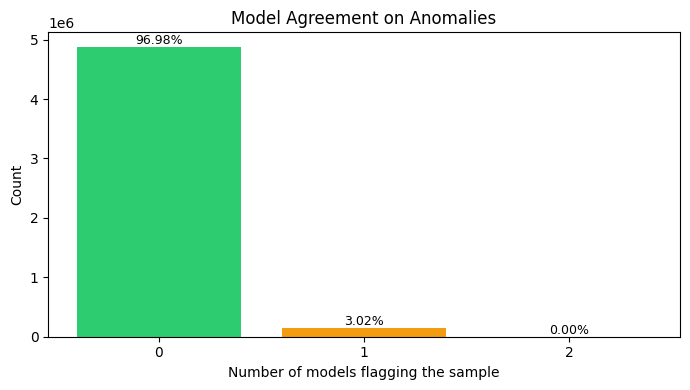

In [8]:
from itertools import combinations

n_total = min(len(all_preds[mt]) for mt in MODEL_TYPES)

pred_matrix = np.column_stack([all_preds[mt][:n_total] for mt in MODEL_TYPES])
n_models_flagged = pred_matrix.sum(axis=1)

agreement_counts = pd.Series(n_models_flagged).value_counts().sort_index()
agreement_counts.index.name = "# Models flagging"
agreement_df = agreement_counts.reset_index()
agreement_df.columns = ["Models Agreeing", "Sample Count"]
agreement_df["Pct (%)"] = (100 * agreement_df["Sample Count"] / n_total).round(3)
print("Model agreement distribution:")
display(agreement_df)

print("\nPairwise overlap (samples flagged by two models):")
for m1, m2 in combinations(MODEL_TYPES, 2):
    overlap = (all_preds[m1][:n_total] & all_preds[m2][:n_total]).sum()
    print(f"  {m1} & {m2}: {overlap}")

n_unanimous = (n_models_flagged == 3).sum()
n_majority  = (n_models_flagged >= 2).sum()
print(f"\nUnanimous (3/3): {n_unanimous} samples ({100*n_unanimous/n_total:.3f}%)")
print(f"Majority  (>=2/3): {n_majority} samples ({100*n_majority/n_total:.3f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(agreement_df["Models Agreeing"].astype(str), agreement_df["Sample Count"], color=["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"])
ax.set_xlabel("Number of models flagging the sample")
ax.set_ylabel("Count")
ax.set_title("Model Agreement on Anomalies")
for bar, pct in zip(bars, agreement_df["Pct (%)"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{pct:.2f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## LOB Deep Dive: Top Anomalies

For the **top anomaly of each model** and the **top consensus anomaly** (if any):
1. Reconstruct the raw limit order book around the event.
2. Visualise the order book depth (bid/ask volumes across 10 levels).
3. Show how key features evolve through the anomaly window.
4. Highlight the exact anomaly timestamp.

In [10]:
raw_lob_days = []
raw_features_days = []
for test_file in TEST_FILES:
    df_raw, feat_raw = load_processed(test_file, "xltime", LOB_COLUMNS)
    raw_lob_days.append(df_raw)
    raw_features_days.append(feat_raw)
    print(f"Loaded {os.path.basename(test_file)}: {len(df_raw)} raw rows, {len(feat_raw)} feature rows")


Loaded 2015-02-03-TOTF.PA-book.parquet: 1575268 raw rows, 1575268 feature rows
Loaded 2015-02-04-TOTF.PA-book.parquet: 1578831 raw rows, 1578831 feature rows
Loaded 2015-02-05-TOTF.PA-book.parquet: 1358713 raw rows, 1358713 feature rows
Loaded 2017-01-02-TOTF.PA-book.parquet: 115050 raw rows, 115050 feature rows
Loaded 2017-01-03-TOTF.PA-book.parquet: 402328 raw rows, 402328 feature rows


In [11]:
LOB_LEVELS = 10
CONTEXT_WINDOW = 50

from sklearn.preprocessing import MinMaxScaler

norm_matrix = np.column_stack([
    MinMaxScaler().fit_transform(all_scores[mt][:n_total].reshape(-1, 1)).flatten()
    for mt in MODEL_TYPES
])

def seq_idx_to_raw(seq_idx, day_boundaries, warmup=WARMUP_STEPS, seq_len=SEQ_LENGTH):
    """Convert a global sequence index to (day_id, raw_lob_row_index)."""
    for day_id, (lo, hi) in enumerate(zip(day_boundaries[:-1], day_boundaries[1:])):
        if lo <= seq_idx < hi:
            local_idx = seq_idx - lo
            raw_row = warmup + seq_len + local_idx
            return day_id, raw_row
    return 0, warmup + seq_len + seq_idx

anomalies_to_inspect = {}

for mt in MODEL_TYPES:
    scores = all_scores[mt][:n_total]
    top_idx = int(np.argmax(scores))
    day_id, raw_row = seq_idx_to_raw(top_idx, day_boundaries)
    anomalies_to_inspect[f"Top {mt}"] = {
        "seq_idx": top_idx, "day_id": day_id, "raw_row": raw_row,
        "score": scores[top_idx], "model": mt,
    }

if n_unanimous > 0:
    consensus_mask = n_models_flagged == 3
elif n_majority > 0:
    consensus_mask = n_models_flagged >= 2
else:
    consensus_mask = n_models_flagged >= 1

if consensus_mask.any():
    consensus_indices = np.where(consensus_mask)[0]
    consensus_total_score = norm_matrix[consensus_indices].sum(axis=1)
    best_consensus_local = int(np.argmax(consensus_total_score))
    best_consensus_idx = consensus_indices[best_consensus_local]
    day_id, raw_row = seq_idx_to_raw(best_consensus_idx, day_boundaries)
    n_agree = int(n_models_flagged[best_consensus_idx])
    anomalies_to_inspect[f"Top Consensus ({n_agree}/3)"] = {
        "seq_idx": best_consensus_idx, "day_id": day_id, "raw_row": raw_row,
        "score": float(consensus_total_score[best_consensus_local]),
        "model": "consensus",
    }

print("Anomalies selected for deep dive:")
for label, info in anomalies_to_inspect.items():
    period = period_labels_seq[info["seq_idx"]] if info["seq_idx"] < len(period_labels_seq) else "?"
    print(f"  {label:40s} | day={day_names[info['day_id']][:15]:15s} | "
          f"raw_row={info['raw_row']:6d} | period={period:20s} | score={info['score']:.4f}")

Anomalies selected for deep dive:
  Top transformer_ocsvm                    | day=2015-02-03-TOTF | raw_row=412319 | period=rest_of_morning      | score=0.0292
  Top pnn                                  | day=2017-01-02-TOTF | raw_row=113541 | period=american_open        | score=0.0000
  Top prae                                 | day=2017-01-03-TOTF | raw_row=404836 | period=american_open        | score=20672.1289
  Top Consensus (2/3)                      | day=2015-02-03-TOTF | raw_row=440586 | period=rest_of_morning      | score=1.9307



Top transformer_ocsvm
  Day: 2015-02-03-TOTF.PA-book.parquet | Raw row: 412319 | Score: 0.0292


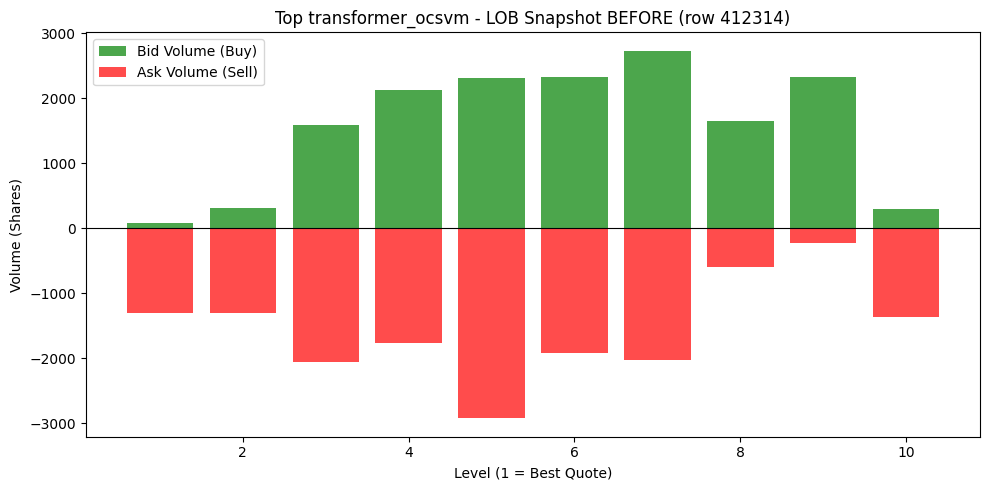

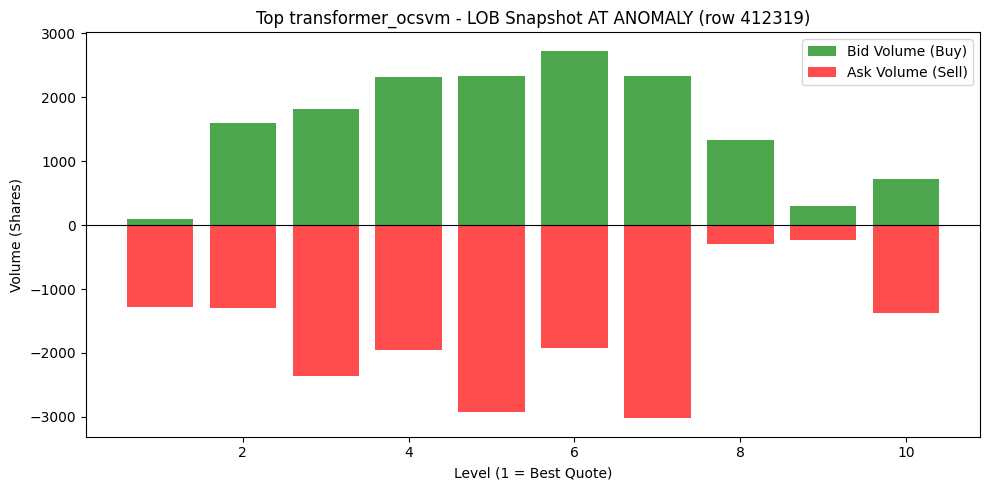

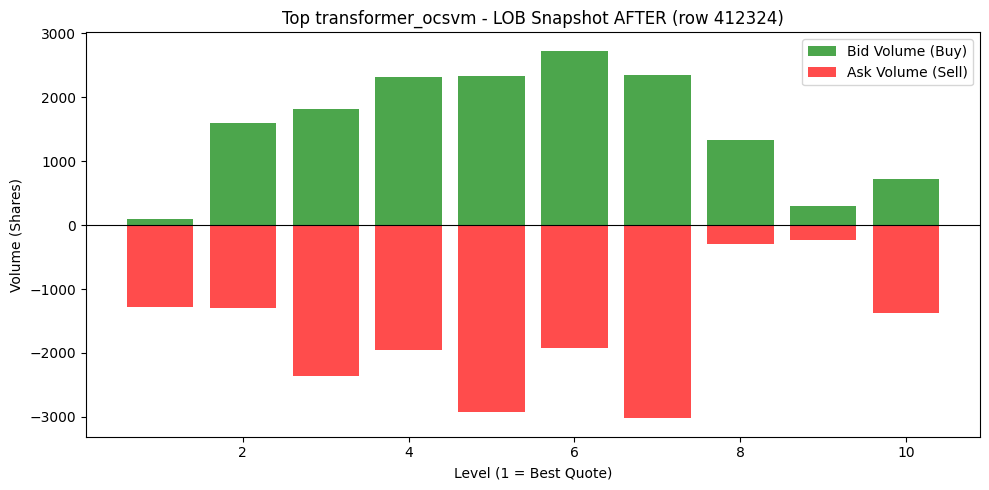

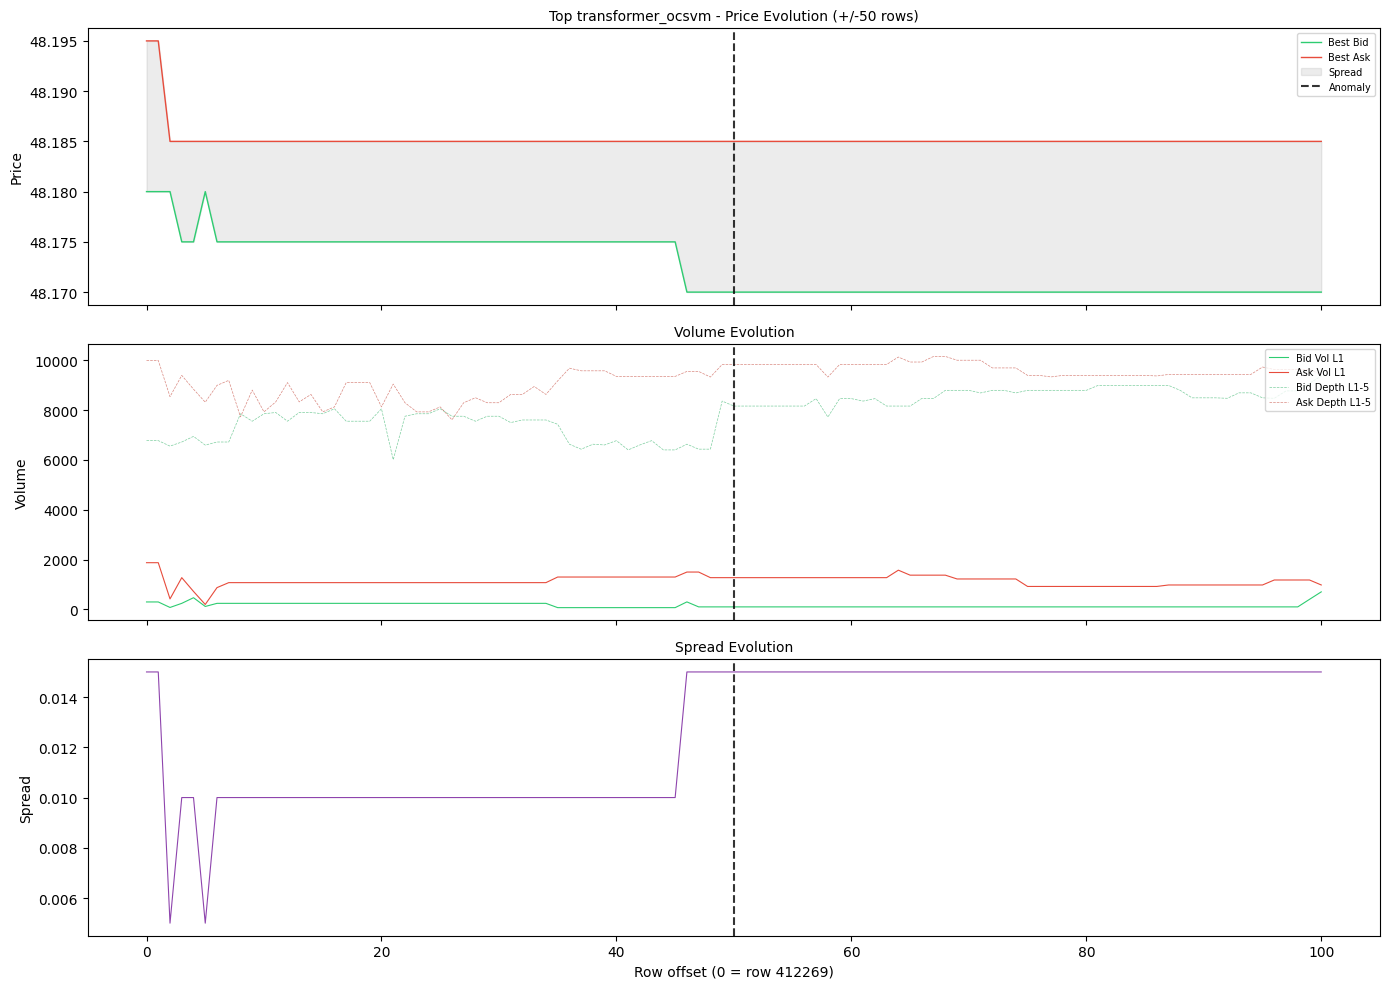


Top pnn
  Day: 2017-01-02-TOTF.PA-book.parquet | Raw row: 113541 | Score: 0.0000


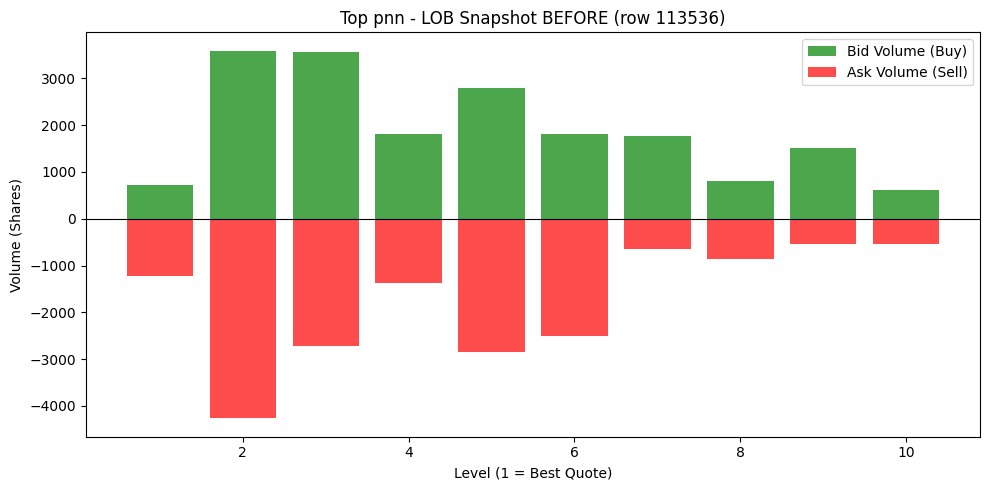

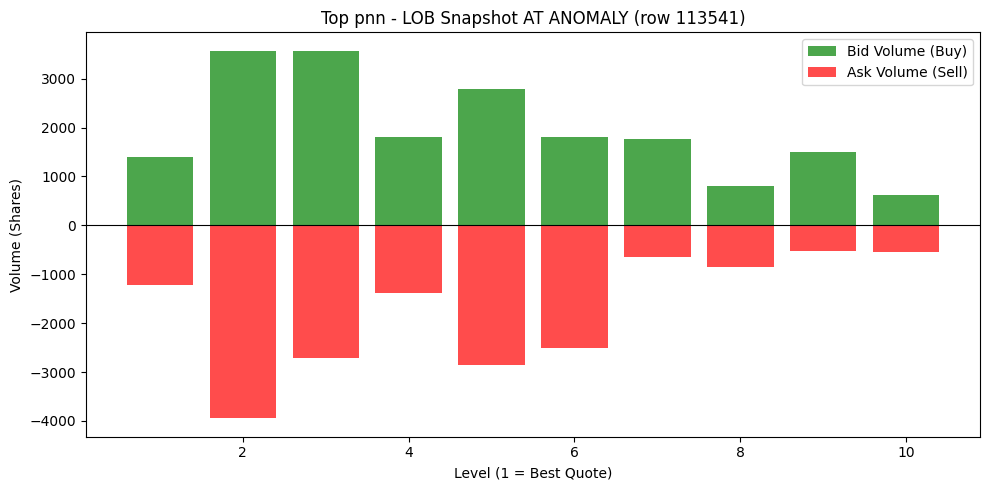

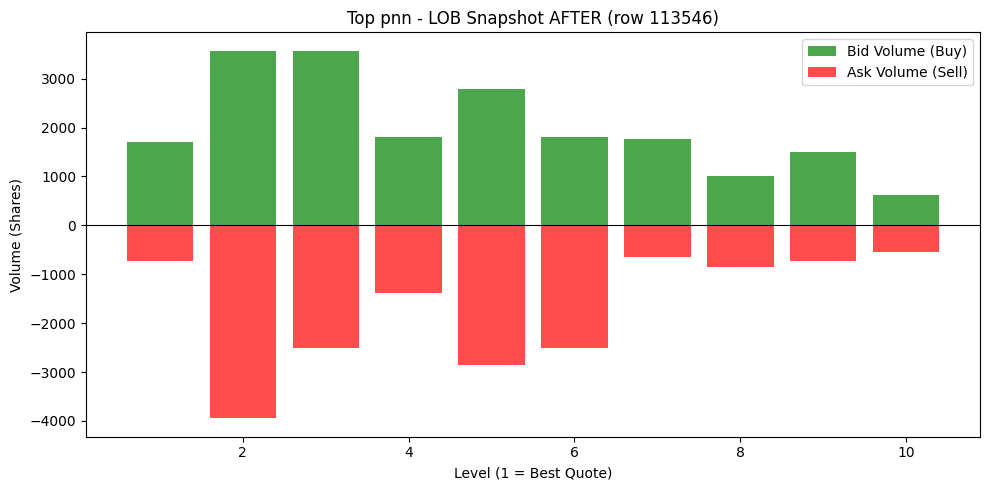

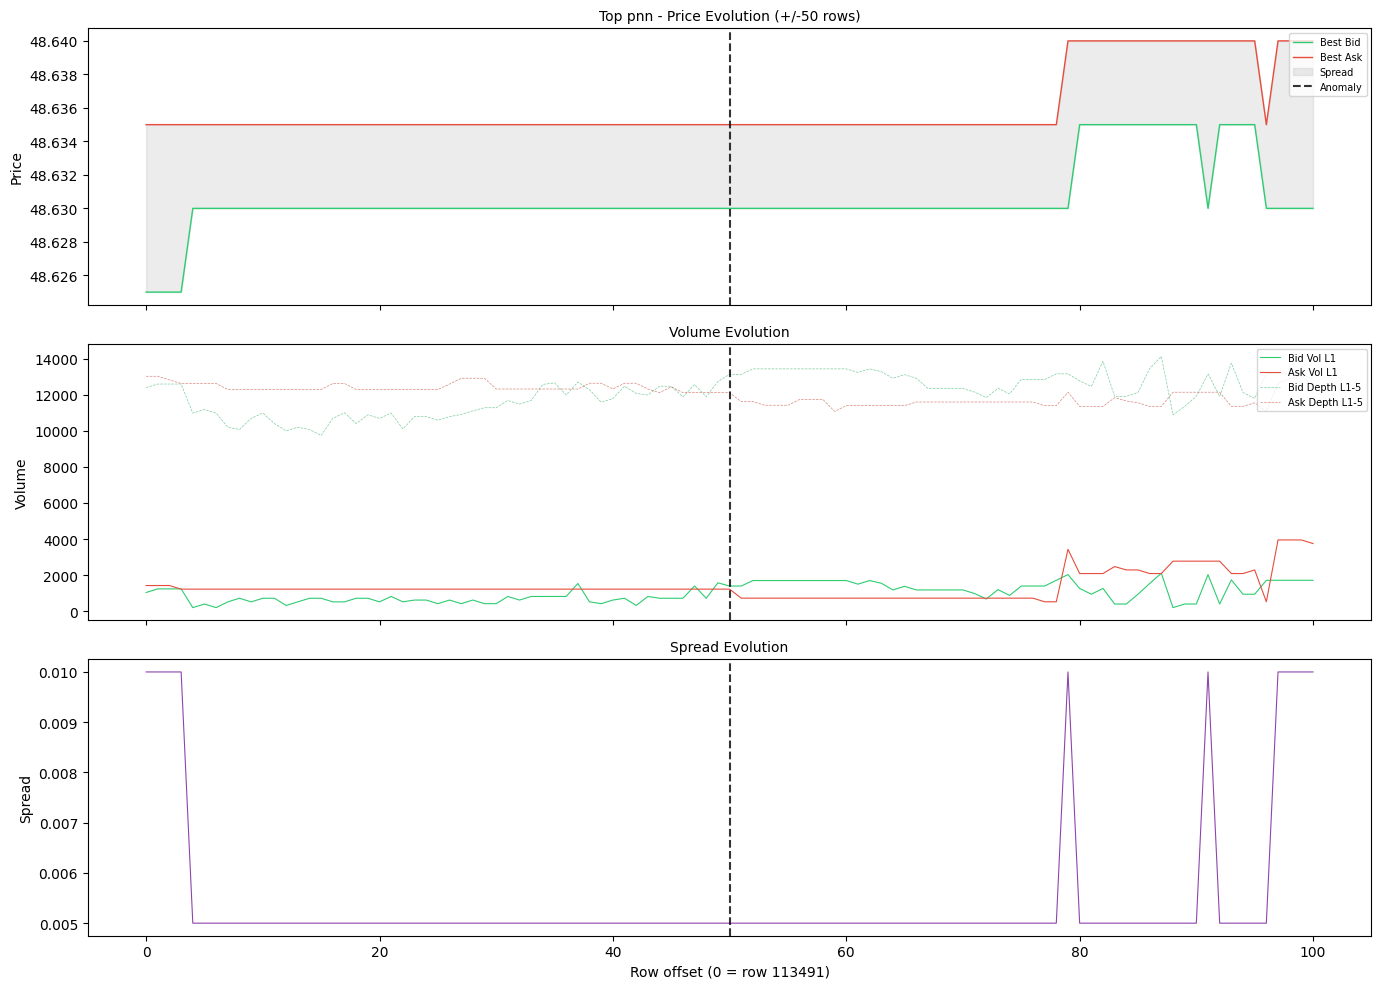


Top prae
  Day: 2017-01-03-TOTF.PA-book.parquet | Raw row: 402327 | Score: 20672.1289


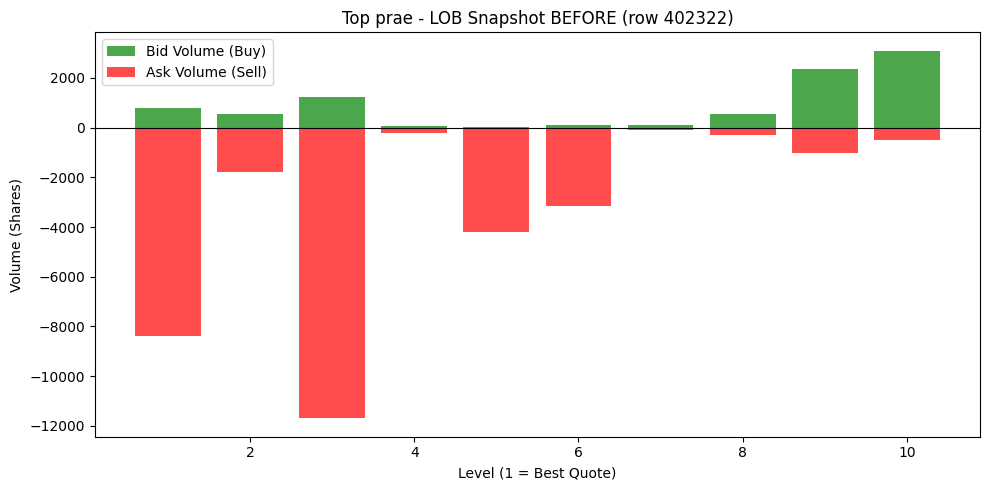

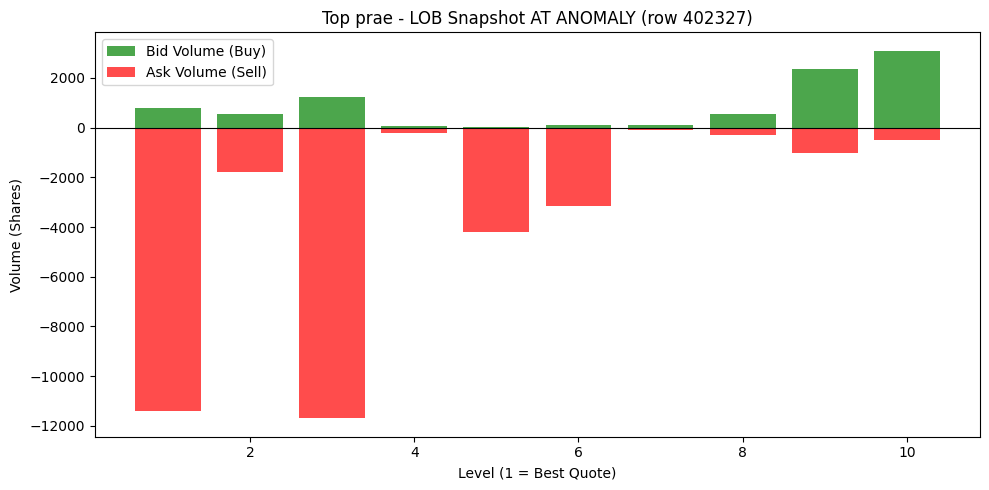

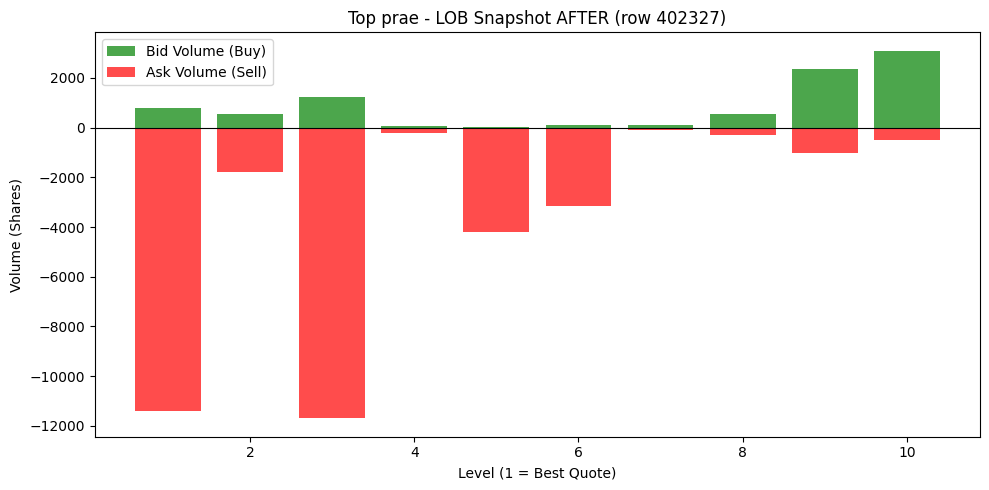

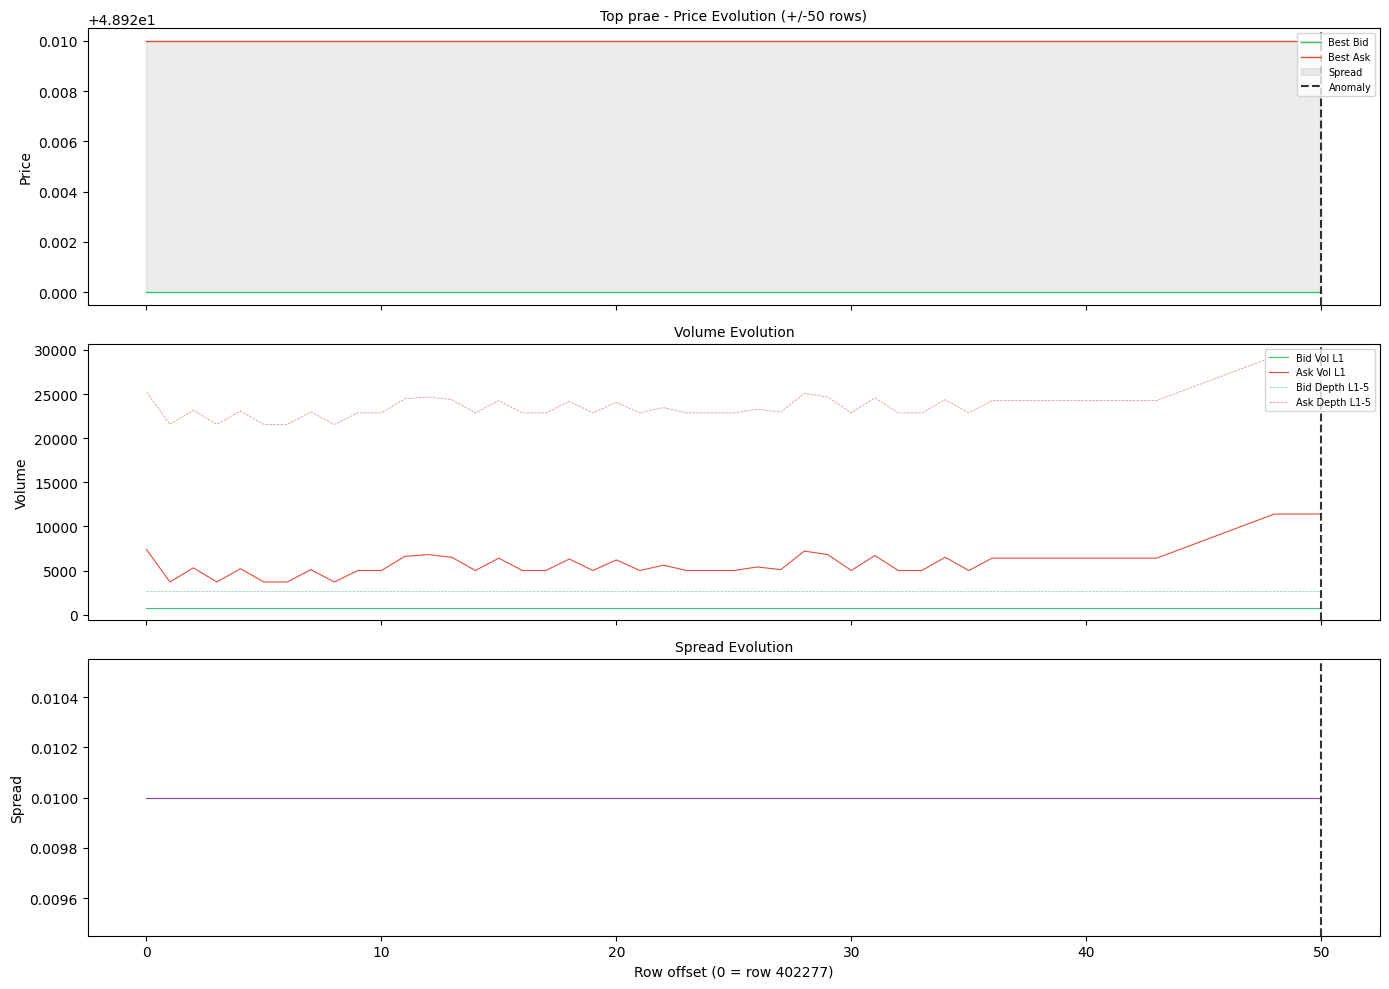


Top Consensus (2/3)
  Day: 2015-02-03-TOTF.PA-book.parquet | Raw row: 440586 | Score: 1.9307


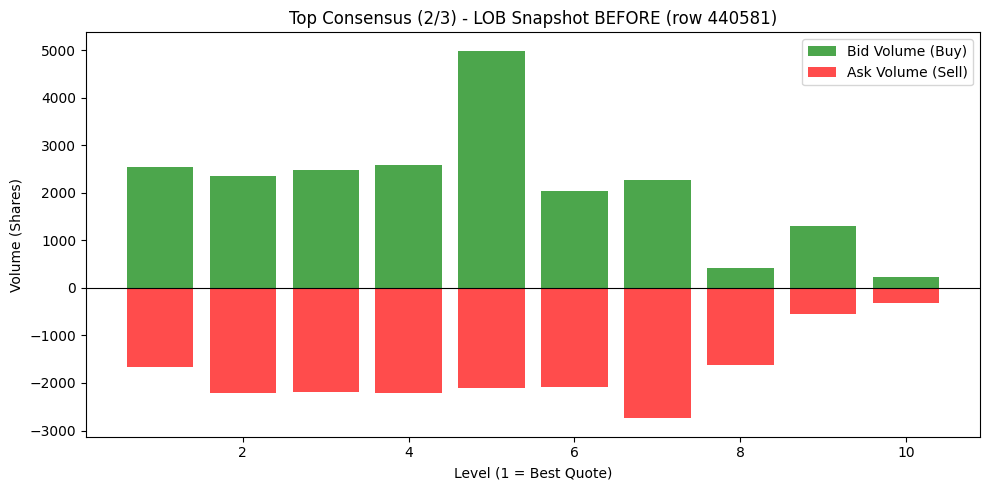

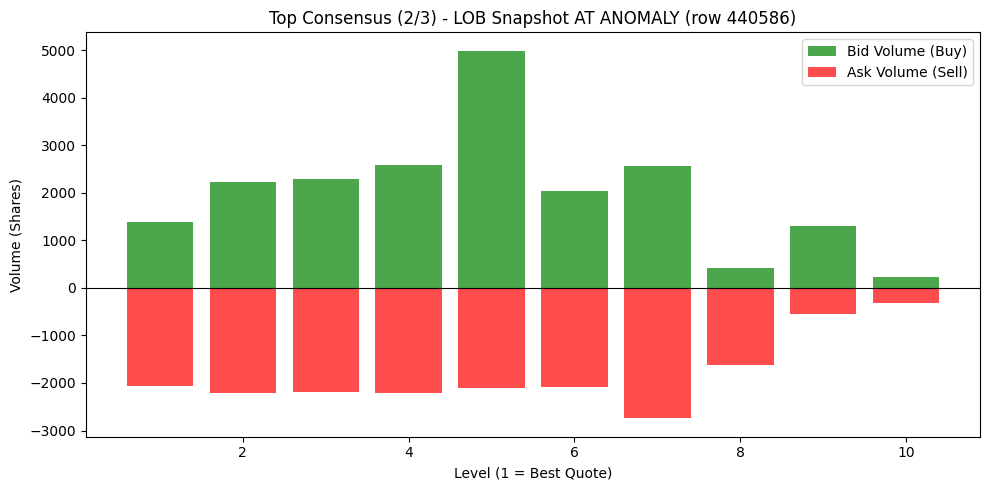

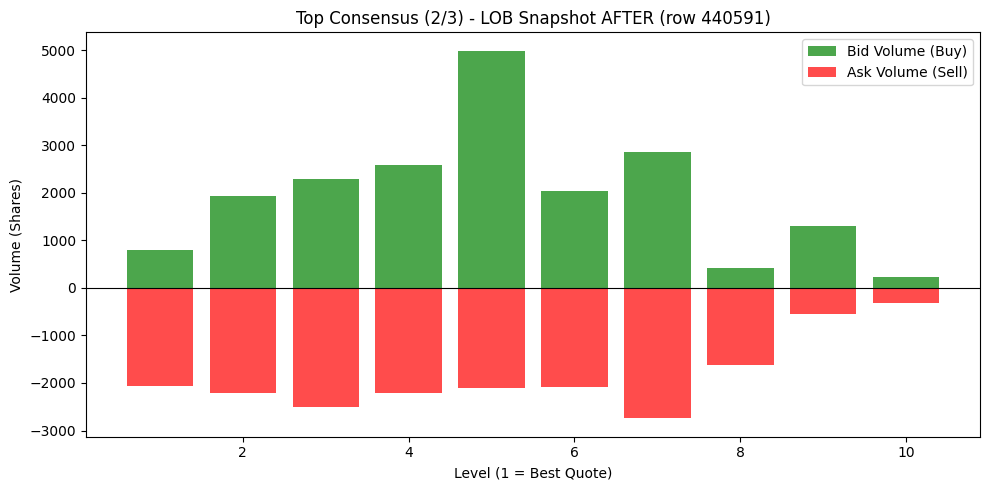

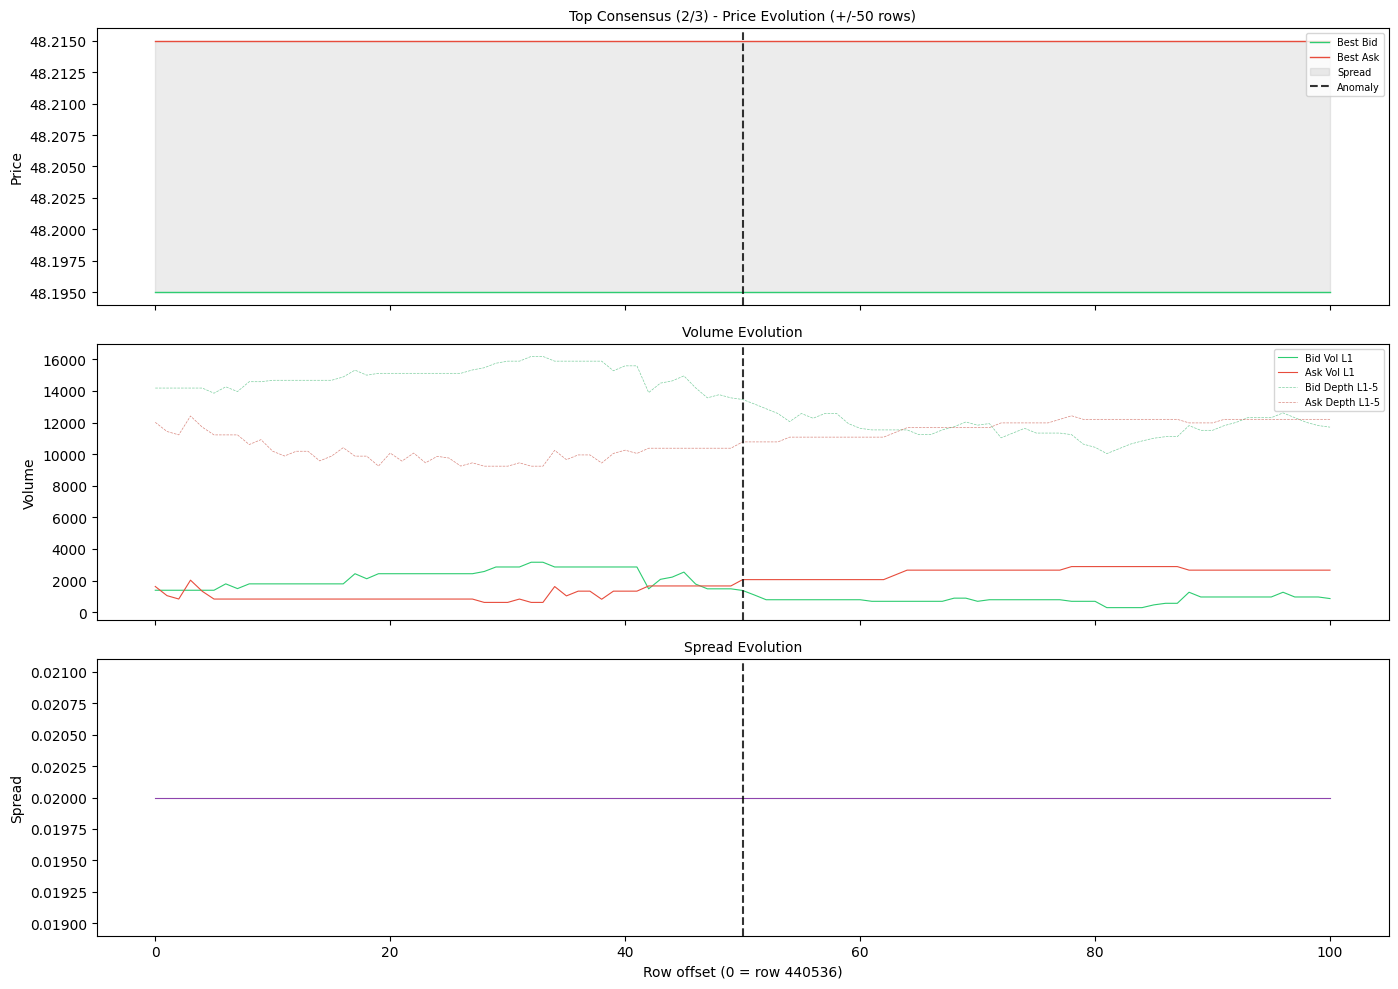

In [12]:
def plot_lob_snapshot(df_raw, center_row, title="", n_levels=LOB_LEVELS):
    """Visualises the Order Book shape at a specific row using vertical bars."""
    row = df_raw.iloc[center_row]

    bids = [row.get(f"bid-volume-{i}", 0) for i in range(1, n_levels + 1)]
    asks = [row.get(f"ask-volume-{i}", 0) for i in range(1, n_levels + 1)]

    x = np.arange(1, n_levels + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x, bids, color="green", label="Bid Volume (Buy)", alpha=0.7)
    ax.bar(x, [-a for a in asks], color="red", label="Ask Volume (Sell)", alpha=0.7)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Level (1 = Best Quote)")
    ax.set_ylabel("Volume (Shares)")
    ax.set_title(title if title else f"LOB Snapshot at Row {center_row}")
    ax.legend()
    plt.tight_layout()
    return fig


def plot_lob_evolution(df_raw, center_row, window=CONTEXT_WINDOW, title=""):
    """Plot bid/ask price and volume evolution around the anomaly."""
    start = max(0, center_row - window)
    end = min(len(df_raw), center_row + window + 1)
    subset = df_raw.iloc[start:end].copy()
    x = np.arange(len(subset))
    anomaly_x = center_row - start

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    ax = axes[0]
    ax.plot(x, subset["bid-price-1"], color="#2ecc71", linewidth=1, label="Best Bid")
    ax.plot(x, subset["ask-price-1"], color="#e74c3c", linewidth=1, label="Best Ask")
    ax.fill_between(x, subset["bid-price-1"], subset["ask-price-1"], alpha=0.15, color="grey", label="Spread")
    ax.axvline(anomaly_x, color="black", linestyle="--", linewidth=1.5, alpha=0.8, label="Anomaly")
    ax.set_ylabel("Price")
    ax.set_title(f"{title} - Price Evolution (+/-{window} rows)", fontsize=10)
    ax.legend(loc="upper right", fontsize=7)

    ax = axes[1]
    ax.plot(x, subset["bid-volume-1"], color="#2ecc71", linewidth=0.8, label="Bid Vol L1")
    ax.plot(x, subset["ask-volume-1"], color="#e74c3c", linewidth=0.8, label="Ask Vol L1")
    bid_depth_5 = sum(subset.get(f"bid-volume-{i+1}", 0) for i in range(5))
    ask_depth_5 = sum(subset.get(f"ask-volume-{i+1}", 0) for i in range(5))
    ax.plot(x, bid_depth_5, color="#27ae60", linewidth=0.5, linestyle="--", alpha=0.6, label="Bid Depth L1-5")
    ax.plot(x, ask_depth_5, color="#c0392b", linewidth=0.5, linestyle="--", alpha=0.6, label="Ask Depth L1-5")
    ax.axvline(anomaly_x, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
    ax.set_ylabel("Volume")
    ax.set_title("Volume Evolution", fontsize=10)
    ax.legend(loc="upper right", fontsize=7)

    ax = axes[2]
    spread = subset["ask-price-1"] - subset["bid-price-1"]
    ax.plot(x, spread, color="#8e44ad", linewidth=0.8)
    ax.axvline(anomaly_x, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
    ax.set_ylabel("Spread")
    ax.set_xlabel(f"Row offset (0 = row {start})")
    ax.set_title("Spread Evolution", fontsize=10)

    plt.tight_layout()
    return fig


for label, info in anomalies_to_inspect.items():
    day_id = info["day_id"]
    raw_row = info["raw_row"]
    df_raw = raw_lob_days[day_id]
    raw_row = min(raw_row, len(df_raw) - 1)

    print(f"\n{label}")
    print(f"  Day: {day_names[day_id]} | Raw row: {raw_row} | Score: {info['score']:.4f}")

    before_row = max(0, raw_row - 5)
    plot_lob_snapshot(df_raw, before_row,
                      title=f"{label} - LOB Snapshot BEFORE (row {before_row})")
    plt.show()

    plot_lob_snapshot(df_raw, raw_row,
                      title=f"{label} - LOB Snapshot AT ANOMALY (row {raw_row})")
    plt.show()

    after_row = min(len(df_raw) - 1, raw_row + 5)
    plot_lob_snapshot(df_raw, after_row,
                      title=f"{label} - LOB Snapshot AFTER (row {after_row})")
    plt.show()

    plot_lob_evolution(df_raw, raw_row, window=CONTEXT_WINDOW, title=label)
    plt.show()

## Feature Evolution Around Anomalies

For each top anomaly, examine how the **most anomalous features** (by z-score) evolve in a window around the event:
- Whether features spike suddenly (impulsive manipulation) or drift gradually.
- Which features jump first (potential leading indicators).
- How quickly the book recovers after the anomalous state.


FEATURE EVOLUTION: Top transformer_ocsvm
Top 8 features by |z-score| at anomaly:
  rapidity_trade_bid                        z=   5.50  val=12342968.430355
  ask_price_speed                           z=   5.12  val=-1281.520889
  ask_log_return                            z=   5.12  val=-0.000104
  order_flow_imbalance_level_1              z=   4.95  val=-1700.000000
  log_return                                z=   3.38  val=-0.000052
  mid_price_velocity                        z=   3.37  val=-0.002500
  abs_velocity                              z=   3.07  val=0.000052
  size_trade_bid                            z=   2.79  val=721.000000


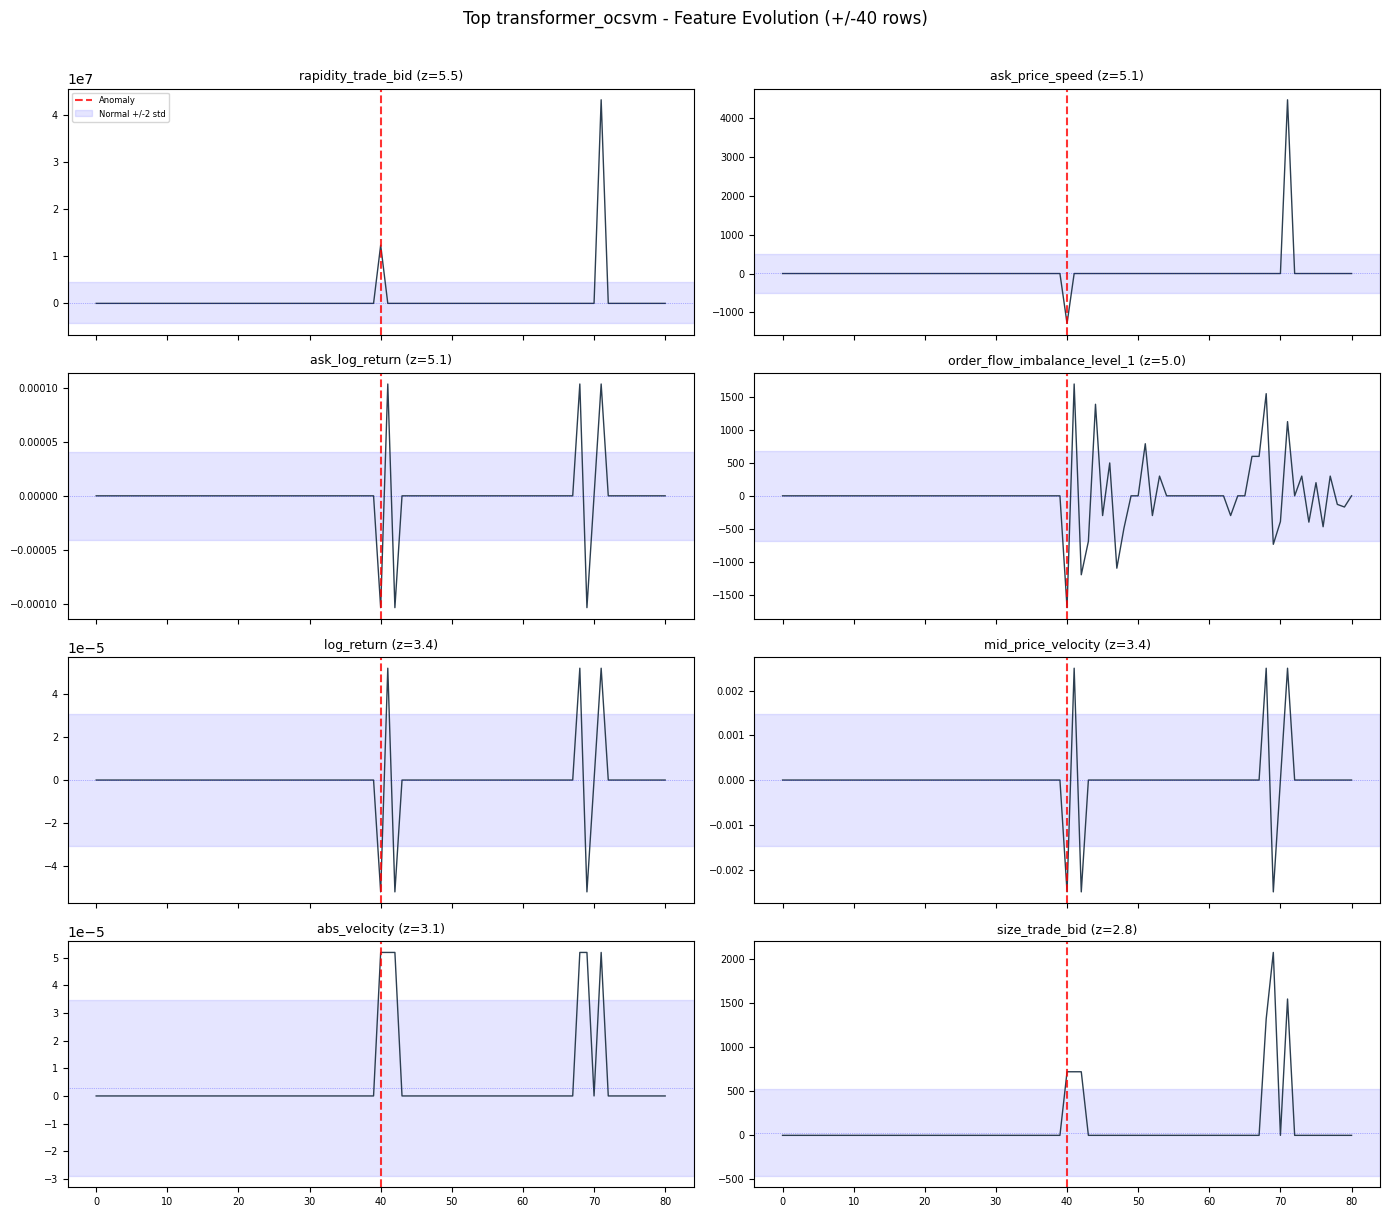


Feature values before / at / after the anomaly:


,Before (-5),Before (-1),At Anomaly,After (+1),After (+5),Delta (before to at),Delta (at to after)
Feature,,,,,,,
rapidity_trade_bid,0.0,0.0,1.234297e+07,1000.000000,0.0,1.234297e+07,-1.234197e+07
ask_price_speed,0.0,0.0,-1.281521e+03,0.103826,0.0,-1.281521e+03,1.281625e+03
ask_log_return,0.0,0.0,-1.040000e-04,0.000104,0.0,-1.040000e-04,2.080000e-04
order_flow_imbalance_level_1,0.0,0.0,-1.700000e+03,1700.000000,-300.0,-1.700000e+03,3.400000e+03
log_return,0.0,0.0,-5.200000e-05,0.000052,0.0,-5.200000e-05,1.040000e-04
mid_price_velocity,0.0,0.0,-2.500000e-03,0.002500,0.0,-2.500000e-03,5.000000e-03
abs_velocity,0.0,0.0,5.200000e-05,0.000052,0.0,5.200000e-05,-0.000000e+00
size_trade_bid,0.0,0.0,7.210000e+02,721.000000,0.0,7.210000e+02,0.000000e+00



FEATURE EVOLUTION: Top pnn
Top 8 features by |z-score| at anomaly:
  size_trade_ask                            z=  13.00  val=5916.804000
  SMA_trade_ask                             z=  12.48  val=3061.315800
  ask_volume_delta                          z=   9.55  val=-5208.020000
  Hawkes_L_ask_beta10_Eta0.001              z=   7.77  val=3764.660822
  Hawkes_L_bid_beta10_Eta0.001              z=   6.60  val=3720.860834
  mid_price_acceleration                    z=   6.46  val=-0.015000
  order_flow_imbalance_level_2              z=   6.44  val=-7411.677000
  bid_log_return                            z=   5.60  val=-0.000205


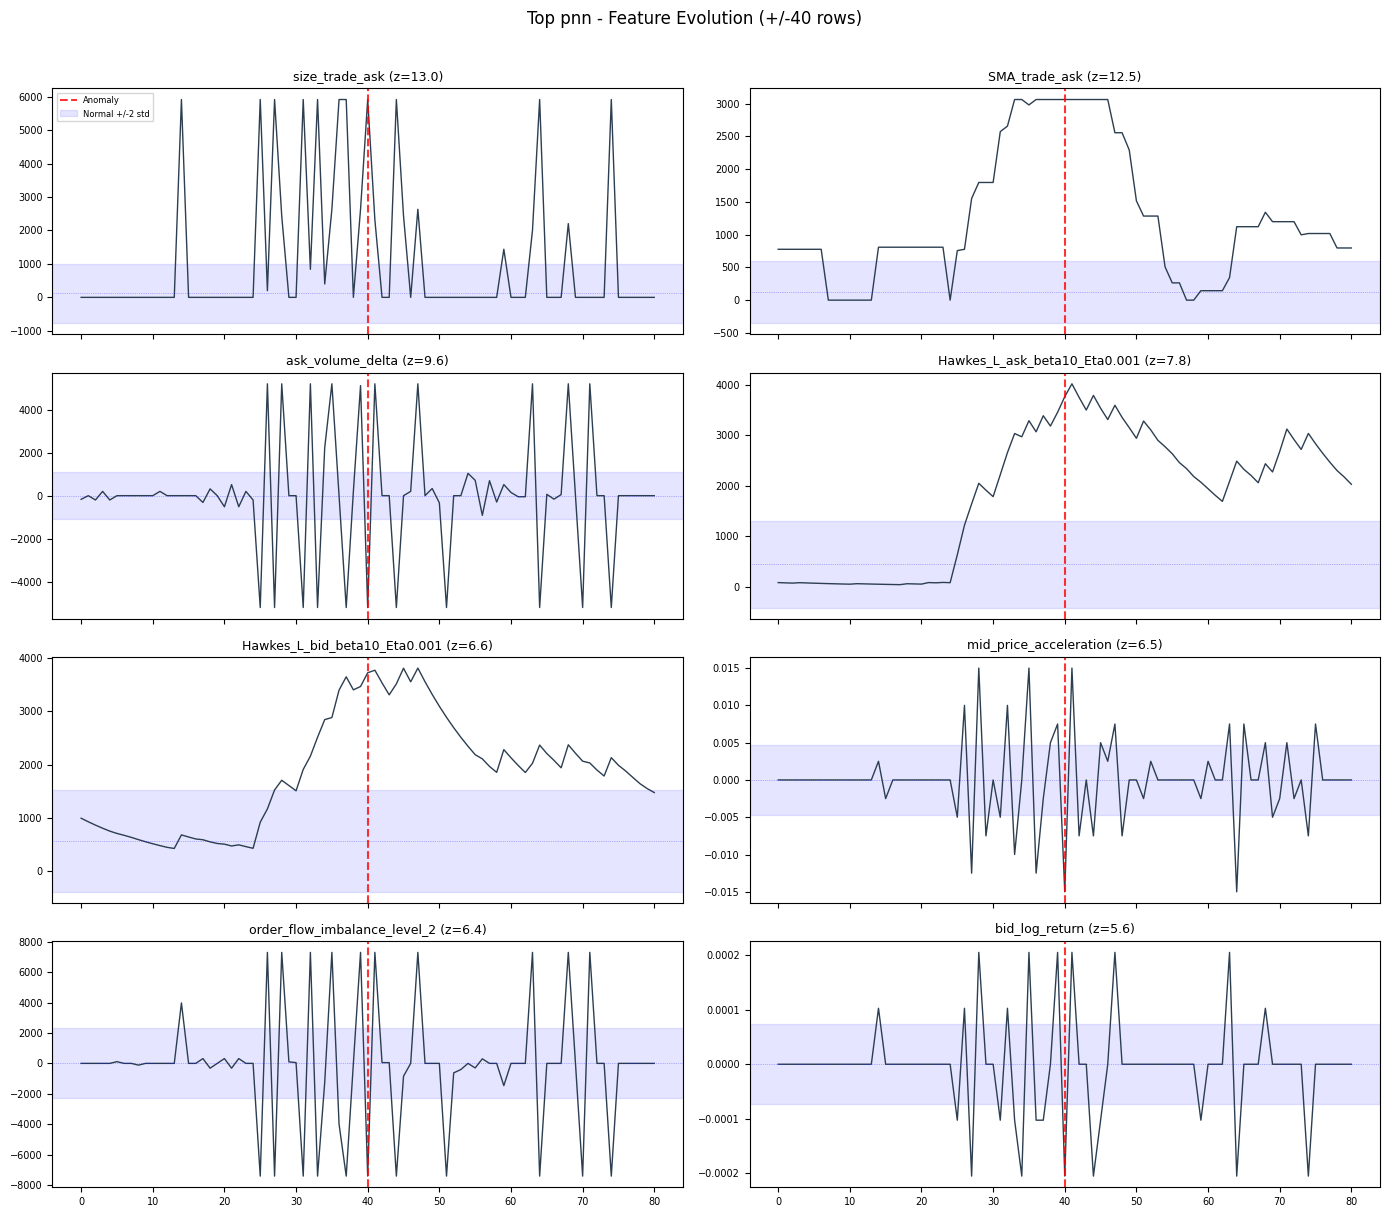


Feature values before / at / after the anomaly:


,Before (-5),Before (-1),At Anomaly,After (+1),After (+5),Delta (before to at),Delta (at to after)
Feature,,,,,,,
size_trade_ask,2635.000000,2635.000000,5916.804000,2319.000000,2435.000000,3281.804000,-3597.804000
SMA_trade_ask,2978.900000,3061.315800,3061.315800,3061.315800,3061.315800,0.000000,0.000000
ask_volume_delta,5209.000000,5125.000000,-5208.020000,5209.000000,0.000000,-10333.020000,10417.020000
Hawkes_L_ask_beta10_Eta0.001,3287.913838,3455.372874,3764.660822,4019.577245,3535.368866,309.287948,254.916424
Hawkes_L_bid_beta10_Eta0.001,2882.070031,3464.130048,3720.860834,3768.771047,3806.103272,256.730785,47.910214
mid_price_acceleration,0.015000,0.007500,-0.015000,0.015000,0.005000,-0.022500,0.030000
order_flow_imbalance_level_2,7300.000000,7300.000000,-7411.677000,7300.000000,-843.000000,-14711.677000,14711.677000
bid_log_return,0.000205,0.000205,-0.000205,0.000205,-0.000103,-0.000411,0.000411



FEATURE EVOLUTION: Top prae
Top 8 features by |z-score| at anomaly:
  Hawkes_L_bid_beta10_Eta10.0               z=  29.62  val=1623.373109
  Hawkes_L_bid_beta10_Eta1.0                z=  29.62  val=1623.373109
  Hawkes_L_bid_beta10_Eta0.1                z=  29.56  val=1623.373109
  Hawkes_L_ask_beta10_Eta1.0                z=  29.49  val=1988.322629
  Hawkes_L_ask_beta10_Eta10.0               z=  29.49  val=1988.322629
  Hawkes_L_ask_beta10_Eta0.1                z=  29.45  val=1988.330015
  Hawkes_M_bid_beta100                      z=  28.28  val=4305.180379
  Hawkes_M_ask_beta100                      z=  28.02  val=6156.512241


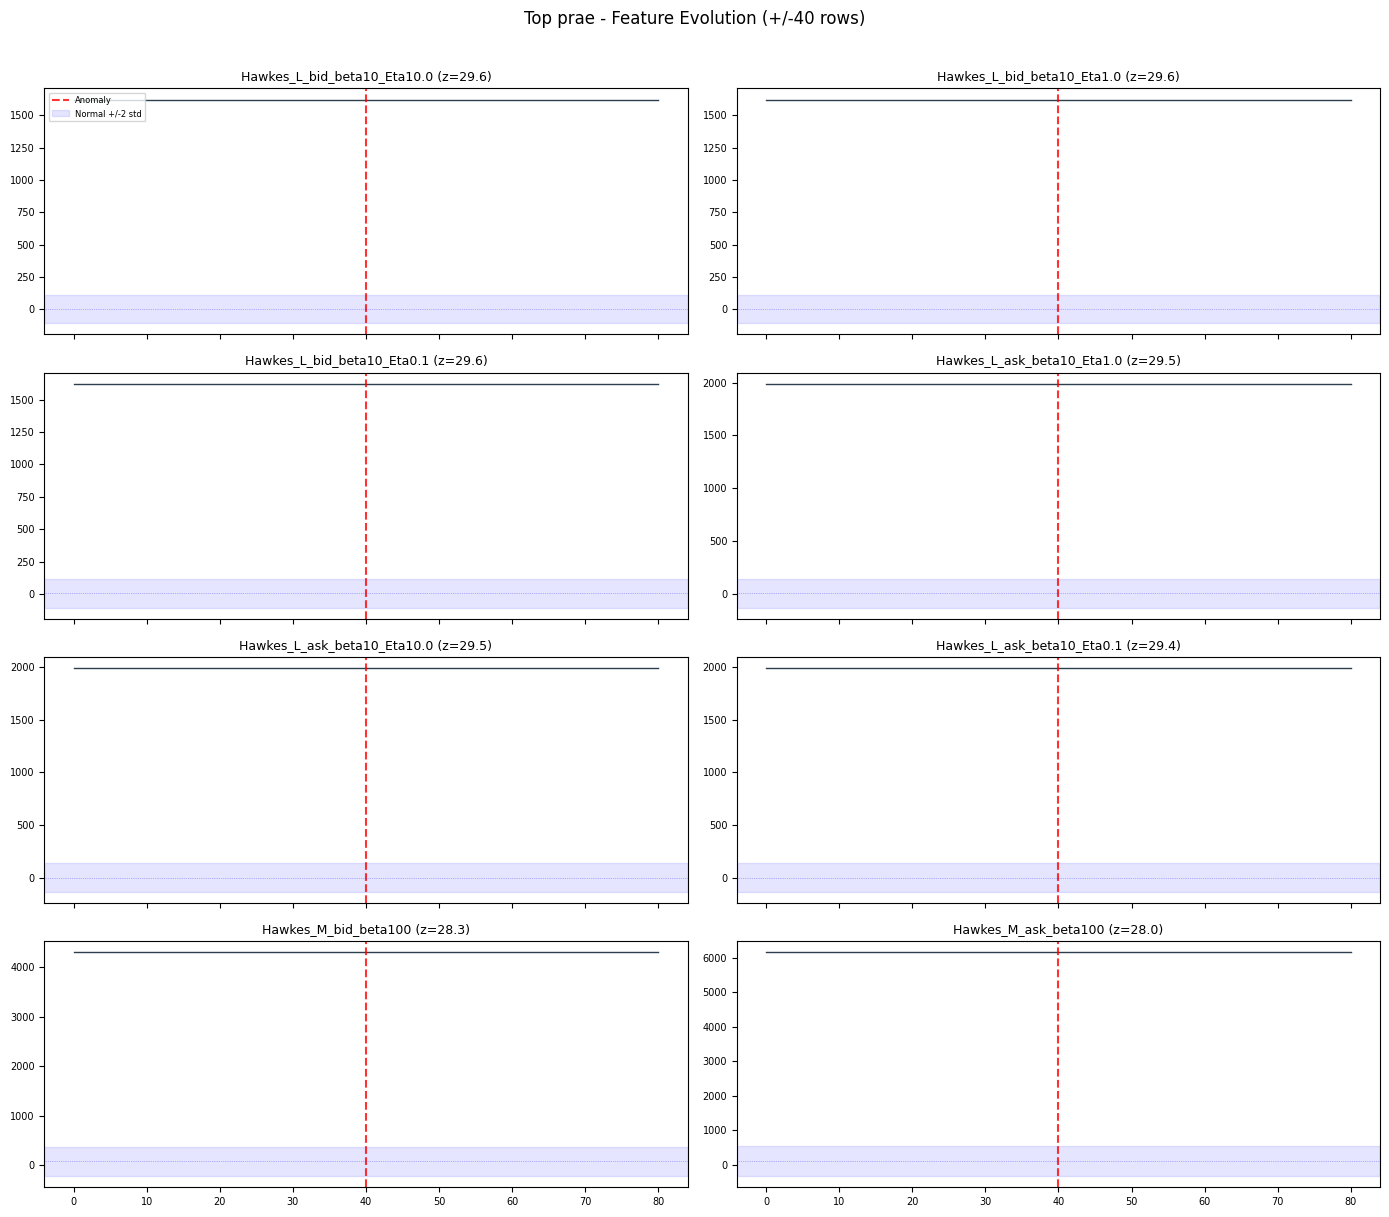


Feature values before / at / after the anomaly:


,Before (-5),Before (-1),At Anomaly,After (+1),After (+5),Delta (before to at),Delta (at to after)
Feature,,,,,,,
Hawkes_L_bid_beta10_Eta10.0,1623.373109,1623.373109,1623.373109,1623.373109,1623.373109,0.0,0.0
Hawkes_L_bid_beta10_Eta1.0,1623.373109,1623.373109,1623.373109,1623.373109,1623.373109,0.0,0.0
Hawkes_L_bid_beta10_Eta0.1,1623.373109,1623.373109,1623.373109,1623.373109,1623.373109,0.0,0.0
Hawkes_L_ask_beta10_Eta1.0,1988.322629,1988.322629,1988.322629,1988.322629,1988.322629,0.0,0.0
Hawkes_L_ask_beta10_Eta10.0,1988.322629,1988.322629,1988.322629,1988.322629,1988.322629,0.0,0.0
Hawkes_L_ask_beta10_Eta0.1,1988.330015,1988.330015,1988.330015,1988.330015,1988.330015,0.0,0.0
Hawkes_M_bid_beta100,4305.180379,4305.180379,4305.180379,4305.180379,4305.180379,0.0,0.0
Hawkes_M_ask_beta100,6156.512241,6156.512241,6156.512241,6156.512241,6156.512241,0.0,0.0



FEATURE EVOLUTION: Top Consensus (2/3)
Top 8 features by |z-score| at anomaly:
  size_trade_ask                            z=   9.86  val=2276.000000
  rapidity_trade_ask                        z=   8.13  val=17279224.726176
  bid_price_speed                           z=   8.03  val=1792.729651
  bid_log_return                            z=   5.54  val=0.000104
  order_flow_imbalance_level_1              z=   4.18  val=1418.000000
  order_flow_imbalance_level_2              z=   3.96  val=2201.000000
  order_flow_imbalance_level_3              z=   3.58  val=2808.000000
  log_return                                z=   3.46  val=0.000052


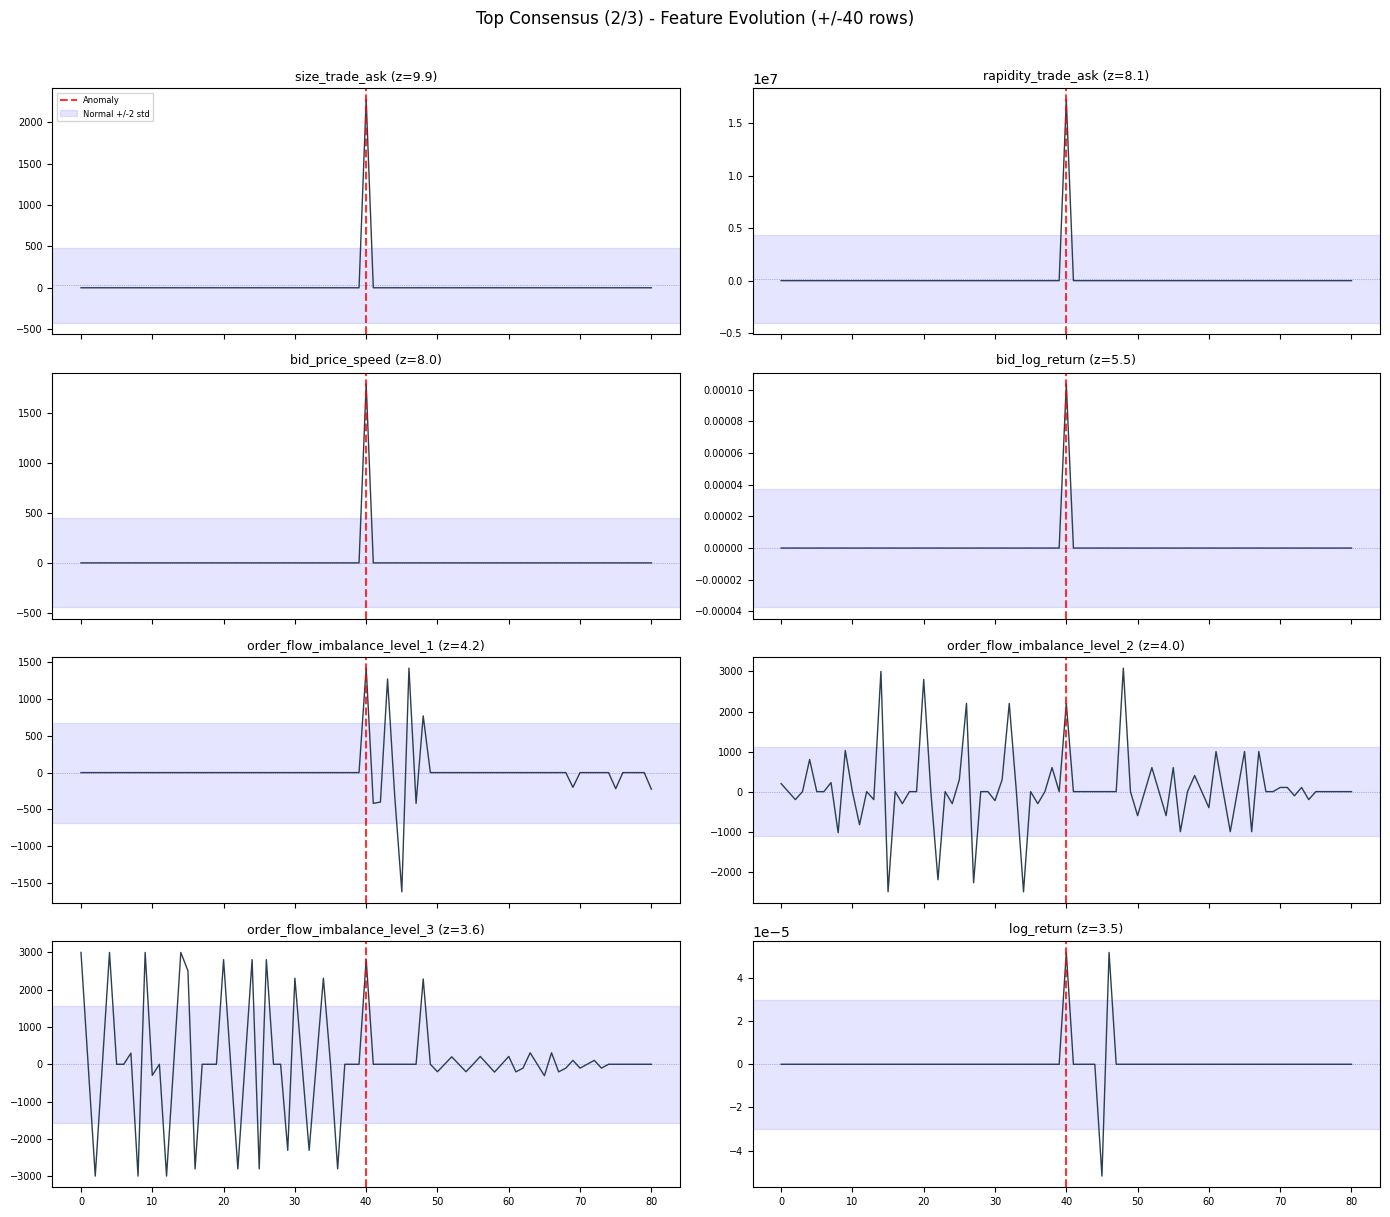


Feature values before / at / after the anomaly:


,Before (-5),Before (-1),At Anomaly,After (+1),After (+5),Delta (before to at),Delta (at to after)
Feature,,,,,,,
size_trade_ask,0.0,0.0,2.276000e+03,0.0,0.000000,2.276000e+03,-2.276000e+03
rapidity_trade_ask,0.0,0.0,1.727922e+07,0.0,0.000000,1.727922e+07,-1.727922e+07
bid_price_speed,0.0,0.0,1.792730e+03,0.0,0.000000,1.792730e+03,-1.792730e+03
bid_log_return,0.0,0.0,1.040000e-04,0.0,0.000000,1.040000e-04,-1.040000e-04
order_flow_imbalance_level_1,0.0,0.0,1.418000e+03,-418.0,-1618.000000,1.418000e+03,-1.836000e+03
order_flow_imbalance_level_2,0.0,0.0,2.201000e+03,0.0,0.000000,2.201000e+03,-2.201000e+03
order_flow_imbalance_level_3,0.0,0.0,2.808000e+03,0.0,0.000000,2.808000e+03,-2.808000e+03
log_return,0.0,0.0,5.200000e-05,0.0,-0.000052,5.200000e-05,-5.200000e-05


In [13]:
TOP_K_FEATURES = 8
FEAT_WINDOW = 40

for label, info in anomalies_to_inspect.items():
    seq_idx = info["seq_idx"]
    day_id = info["day_id"]
    model_name = info["model"]

    feat_day = raw_features_days[day_id]

    day_start = day_boundaries[day_id]
    local_seq_idx = seq_idx - day_start
    feat_row = SEQ_LENGTH + local_seq_idx
    feat_row = min(feat_row, len(feat_day) - 1)

    f_start = max(0, feat_row - FEAT_WINDOW)
    f_end = min(len(feat_day), feat_row + FEAT_WINDOW + 1)
    feat_window = feat_day.iloc[f_start:f_end].copy()
    anomaly_offset = feat_row - f_start

    day_preds_combined = pred_matrix[day_start:day_boundaries[day_id + 1]]
    if model_name == "consensus":
        normal_mask_day = day_preds_combined.sum(axis=1) == 0
    elif model_name in MODEL_TYPES:
        mt_idx = MODEL_TYPES.index(model_name)
        normal_mask_day = day_preds_combined[:, mt_idx] == 0
    else:
        normal_mask_day = np.ones(len(day_preds_combined), dtype=bool)

    day_n_seq = day_boundaries[day_id + 1] - day_boundaries[day_id]
    normal_feat_start = SEQ_LENGTH
    normal_feat_end = SEQ_LENGTH + day_n_seq
    normal_feat_indices = np.arange(normal_feat_start, min(normal_feat_end, len(feat_day)))
    if len(normal_mask_day) > len(normal_feat_indices):
        normal_mask_day = normal_mask_day[:len(normal_feat_indices)]
    normal_feats = feat_day.iloc[normal_feat_indices[normal_mask_day]] if normal_mask_day.sum() > 0 else feat_day

    day_mean = normal_feats.mean()
    day_std = normal_feats.std().replace(0, 1e-10)

    anomaly_feat = feat_day.iloc[feat_row]
    z_at_anomaly = ((anomaly_feat - day_mean) / day_std).abs().sort_values(ascending=False)
    top_features = z_at_anomaly.head(TOP_K_FEATURES).index.tolist()

    print(f"\nFEATURE EVOLUTION: {label}")
    print(f"Top {TOP_K_FEATURES} features by |z-score| at anomaly:")
    for feat_name in top_features:
        print(f"  {feat_name:40s}  z={z_at_anomaly[feat_name]:7.2f}  val={anomaly_feat[feat_name]:.6f}")

    n_feat = len(top_features)
    n_cols = 2
    n_rows = math.ceil(n_feat / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows), sharex=True)
    axes = axes.flatten() if n_feat > 1 else [axes]

    x = np.arange(len(feat_window))
    for ax_i, feat_name in enumerate(top_features):
        ax = axes[ax_i]
        vals = feat_window[feat_name].values
        ax.plot(x, vals, linewidth=1, color="#2c3e50")
        ax.axvline(anomaly_offset, color="red", linestyle="--", linewidth=1.5, alpha=0.8, label="Anomaly")

        m = day_mean[feat_name]
        s = day_std[feat_name]
        ax.axhspan(m - 2*s, m + 2*s, alpha=0.1, color="blue", label="Normal +/-2 std")
        ax.axhline(m, color="blue", linestyle=":", linewidth=0.5, alpha=0.5)

        ax.set_title(f"{feat_name} (z={z_at_anomaly[feat_name]:.1f})", fontsize=9)
        ax.tick_params(labelsize=7)
        if ax_i == 0:
            ax.legend(fontsize=6, loc="upper left")

    for ax_i in range(n_feat, len(axes)):
        axes[ax_i].set_visible(False)

    fig.suptitle(f"{label} - Feature Evolution (+/-{FEAT_WINDOW} rows)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    delta_rows = []
    offsets = {"Before (-5)": max(0, feat_row - 5),
               "Before (-1)": max(0, feat_row - 1),
               "At Anomaly":  feat_row,
               "After (+1)":  min(len(feat_day) - 1, feat_row + 1),
               "After (+5)":  min(len(feat_day) - 1, feat_row + 5)}

    for feat_name in top_features:
        row_data = {"Feature": feat_name}
        for offset_label, offset_idx in offsets.items():
            row_data[offset_label] = feat_day.iloc[offset_idx][feat_name]
        row_data["Delta (before to at)"] = row_data["At Anomaly"] - row_data["Before (-1)"]
        row_data["Delta (at to after)"]  = row_data["After (+1)"] - row_data["At Anomaly"]
        delta_rows.append(row_data)

    delta_df = pd.DataFrame(delta_rows)
    print(f"\nFeature values before / at / after the anomaly:")
    display(delta_df.set_index("Feature").round(6))

## LOB State Comparison: Before vs After Anomaly

Side-by-side comparison of the full 10-level order book immediately before and after each top anomaly.


Top transformer_ocsvm - LOB State Comparison

  BEFORE (row 412318):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.170,103.0,48.185,1276.0
2,48.165,1591.0,48.190,1300.0
3,48.160,2019.0,48.195,2364.0
4,48.155,2316.0,48.200,1961.0
5,48.150,2331.0,48.205,2926.0
6,48.145,2730.0,48.210,1921.0
7,48.140,2142.0,48.215,3024.0
8,48.135,1332.0,48.220,298.0
9,48.130,298.0,48.230,228.0



  Changes BEFORE to AT ANOMALY:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,-200.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,200.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AT ANOMALY (row 412319):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.170,103.0,48.185,1276.0
2,48.165,1591.0,48.190,1300.0
3,48.160,1819.0,48.195,2364.0
4,48.155,2316.0,48.200,1961.0
5,48.150,2331.0,48.205,2926.0
6,48.145,2730.0,48.210,1921.0
7,48.140,2342.0,48.215,3024.0
8,48.135,1332.0,48.220,298.0
9,48.130,298.0,48.230,228.0



  Changes AT ANOMALY to AFTER:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,-700.000000,0.000000,0.000000
8,0.000000,1000.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AFTER (row 412320):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.170,103.0,48.185,1276.0
2,48.165,1591.0,48.190,1300.0
3,48.160,1819.0,48.195,2364.0
4,48.155,2316.0,48.200,1961.0
5,48.150,2331.0,48.205,2926.0
6,48.145,2730.0,48.210,1921.0
7,48.140,1642.0,48.215,3024.0
8,48.135,2332.0,48.220,298.0
9,48.130,298.0,48.230,228.0


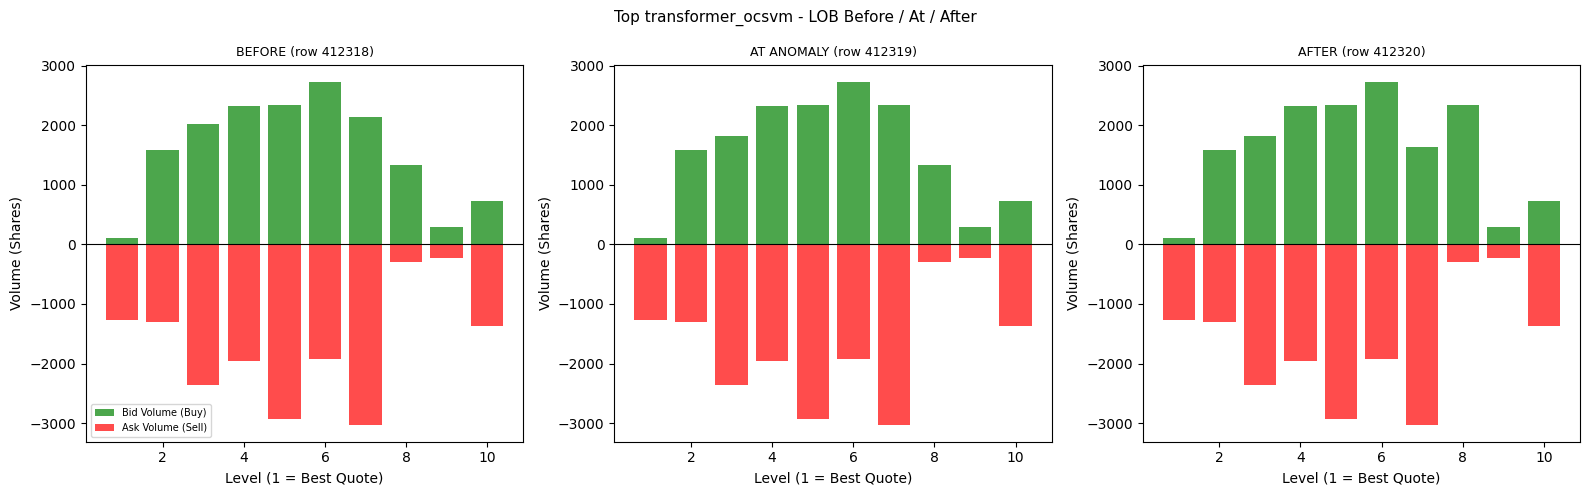


Top pnn - LOB State Comparison

  BEFORE (row 113540):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.630,1575.0,48.635,1225.0
2,48.625,3005.0,48.640,3947.0
3,48.620,3559.0,48.645,2712.0
4,48.615,1810.0,48.650,1383.0
5,48.610,2788.0,48.655,2847.0
6,48.605,1813.0,48.660,2508.0
7,48.600,1768.0,48.665,645.0
8,48.595,811.0,48.670,856.0
9,48.590,1508.0,48.675,533.0



  Changes BEFORE to AT ANOMALY:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,-178.000000,0.000000,0.000000
2,0.000000,567.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AT ANOMALY (row 113541):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.630,1397.0,48.635,1225.0
2,48.625,3572.0,48.640,3947.0
3,48.620,3559.0,48.645,2712.0
4,48.615,1810.0,48.650,1383.0
5,48.610,2788.0,48.655,2847.0
6,48.605,1813.0,48.660,2508.0
7,48.600,1768.0,48.665,645.0
8,48.595,811.0,48.670,856.0
9,48.590,1508.0,48.675,533.0



  Changes AT ANOMALY to AFTER:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,0.000000,0.000000,-500.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AFTER (row 113542):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.630,1397.0,48.635,725.0
2,48.625,3572.0,48.640,3947.0
3,48.620,3559.0,48.645,2712.0
4,48.615,1810.0,48.650,1383.0
5,48.610,2788.0,48.655,2847.0
6,48.605,1813.0,48.660,2508.0
7,48.600,1768.0,48.665,645.0
8,48.595,811.0,48.670,856.0
9,48.590,1508.0,48.675,533.0


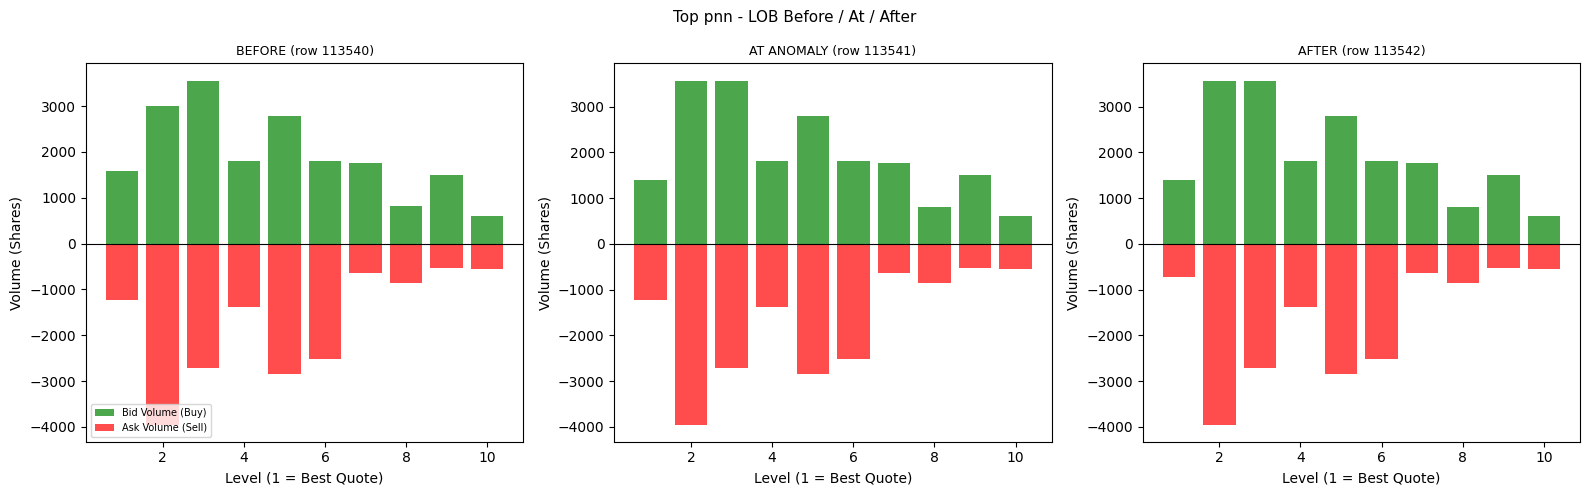


Top prae - LOB State Comparison

  BEFORE (row 402326):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.920,791.0,48.930,11400.0
2,48.915,539.0,48.940,1773.0
3,48.910,1216.0,48.950,11696.0
4,48.900,50.0,48.955,203.0
5,48.890,30.0,48.960,4194.0
6,48.880,100.0,48.970,3140.0
7,48.870,100.0,48.975,100.0
8,48.855,568.0,48.980,300.0
9,48.850,2355.0,48.985,1000.0



  Changes BEFORE to AT ANOMALY:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AT ANOMALY (row 402327):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.920,791.0,48.930,11400.0
2,48.915,539.0,48.940,1773.0
3,48.910,1216.0,48.950,11696.0
4,48.900,50.0,48.955,203.0
5,48.890,30.0,48.960,4194.0
6,48.880,100.0,48.970,3140.0
7,48.870,100.0,48.975,100.0
8,48.855,568.0,48.980,300.0
9,48.850,2355.0,48.985,1000.0



  Changes AT ANOMALY to AFTER:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AFTER (row 402327):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.920,791.0,48.930,11400.0
2,48.915,539.0,48.940,1773.0
3,48.910,1216.0,48.950,11696.0
4,48.900,50.0,48.955,203.0
5,48.890,30.0,48.960,4194.0
6,48.880,100.0,48.970,3140.0
7,48.870,100.0,48.975,100.0
8,48.855,568.0,48.980,300.0
9,48.850,2355.0,48.985,1000.0


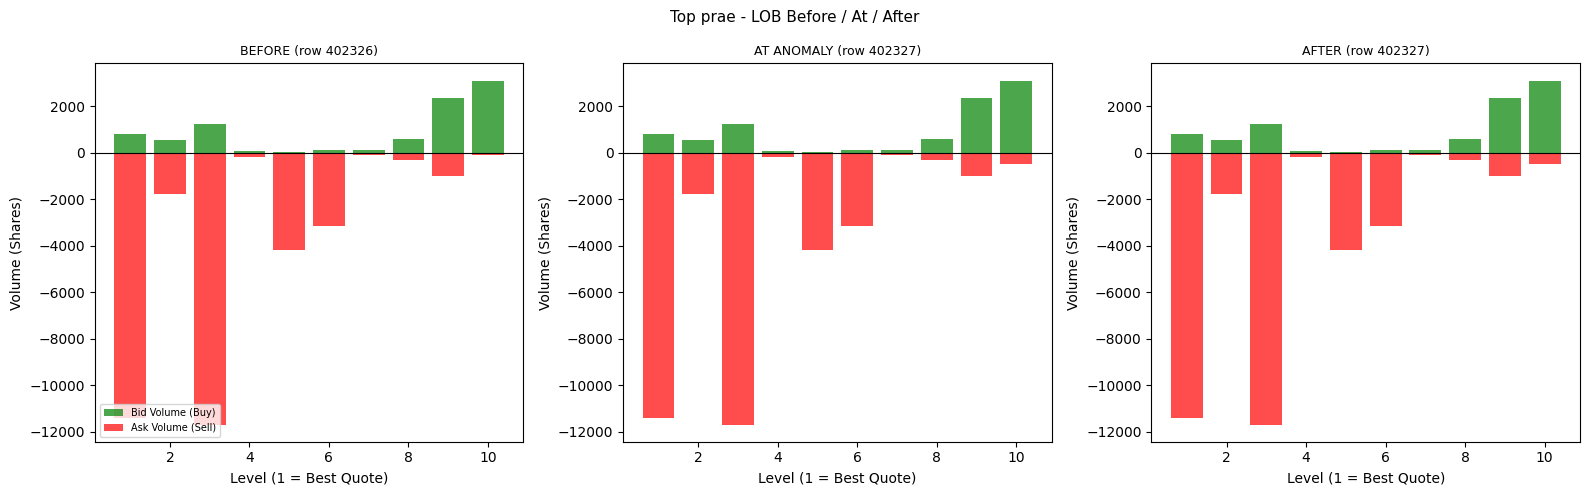


Top Consensus (2/3) - LOB State Comparison

  BEFORE (row 440585):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.195,1479.0,48.215,1661.0
2,48.190,2227.0,48.220,2212.0
3,48.185,2283.0,48.225,2200.0
4,48.180,2586.0,48.230,2203.0
5,48.175,4987.0,48.235,2099.0
6,48.170,2033.0,48.240,2080.0
7,48.165,2558.0,48.245,2744.0
8,48.160,415.0,48.250,1624.0
9,48.155,1298.0,48.255,553.0



  Changes BEFORE to AT ANOMALY:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,-104.000000,0.000000,400.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AT ANOMALY (row 440586):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.195,1375.0,48.215,2061.0
2,48.190,2227.0,48.220,2212.0
3,48.185,2283.0,48.225,2200.0
4,48.180,2586.0,48.230,2203.0
5,48.175,4987.0,48.235,2099.0
6,48.170,2033.0,48.240,2080.0
7,48.165,2558.0,48.245,2744.0
8,48.160,415.0,48.250,1624.0
9,48.155,1298.0,48.255,553.0



  Changes AT ANOMALY to AFTER:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,-286.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AFTER (row 440587):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,48.195,1089.0,48.215,2061.0
2,48.190,2227.0,48.220,2212.0
3,48.185,2283.0,48.225,2200.0
4,48.180,2586.0,48.230,2203.0
5,48.175,4987.0,48.235,2099.0
6,48.170,2033.0,48.240,2080.0
7,48.165,2558.0,48.245,2744.0
8,48.160,415.0,48.250,1624.0
9,48.155,1298.0,48.255,553.0


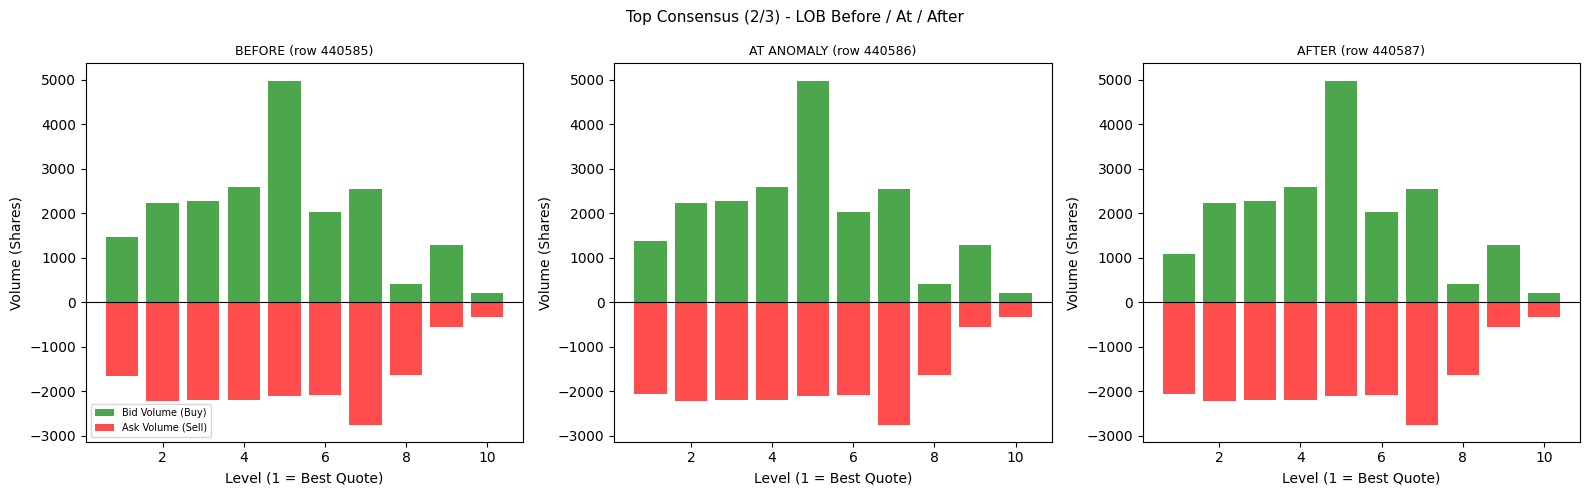

In [14]:
def lob_to_table(df_raw, row_idx, n_levels=LOB_LEVELS):
    """Extract a tidy LOB table for one timestamp."""
    row = df_raw.iloc[row_idx]
    records = []
    for lv in range(1, n_levels + 1):
        records.append({
            "Level": lv,
            "Bid Price":  row.get(f"bid-price-{lv}", np.nan),
            "Bid Volume": row.get(f"bid-volume-{lv}", 0),
            "Ask Price":  row.get(f"ask-price-{lv}", np.nan),
            "Ask Volume": row.get(f"ask-volume-{lv}", 0),
        })
    return pd.DataFrame(records).set_index("Level")


for label, info in anomalies_to_inspect.items():
    day_id = info["day_id"]
    raw_row = min(info["raw_row"], len(raw_lob_days[day_id]) - 1)
    df_raw = raw_lob_days[day_id]

    before_row = max(0, raw_row - 1)
    after_row  = min(len(df_raw) - 1, raw_row + 1)

    lob_before = lob_to_table(df_raw, before_row)
    lob_at     = lob_to_table(df_raw, raw_row)
    lob_after  = lob_to_table(df_raw, after_row)

    print(f"\n{label} - LOB State Comparison")

    delta_before_to_at = pd.DataFrame({
        "Delta Bid Price":  lob_at["Bid Price"]  - lob_before["Bid Price"],
        "Delta Bid Volume": lob_at["Bid Volume"] - lob_before["Bid Volume"],
        "Delta Ask Price":  lob_at["Ask Price"]  - lob_before["Ask Price"],
        "Delta Ask Volume": lob_at["Ask Volume"] - lob_before["Ask Volume"],
    })
    delta_at_to_after = pd.DataFrame({
        "Delta Bid Price":  lob_after["Bid Price"]  - lob_at["Bid Price"],
        "Delta Bid Volume": lob_after["Bid Volume"] - lob_at["Bid Volume"],
        "Delta Ask Price":  lob_after["Ask Price"]  - lob_at["Ask Price"],
        "Delta Ask Volume": lob_after["Ask Volume"] - lob_at["Ask Volume"],
    })

    print(f"\n  BEFORE (row {before_row}):")
    display(lob_before)
    print(f"\n  Changes BEFORE to AT ANOMALY:")
    display(delta_before_to_at.style.applymap(
        lambda v: "color: red; font-weight: bold" if abs(v) > 0 else "", subset=pd.IndexSlice[:, :]))

    print(f"\n  AT ANOMALY (row {raw_row}):")
    display(lob_at)
    print(f"\n  Changes AT ANOMALY to AFTER:")
    display(delta_at_to_after.style.applymap(
        lambda v: "color: red; font-weight: bold" if abs(v) > 0 else "", subset=pd.IndexSlice[:, :]))

    print(f"\n  AFTER (row {after_row}):")
    display(lob_after)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    titles = [f"BEFORE (row {before_row})", f"AT ANOMALY (row {raw_row})", f"AFTER (row {after_row})"]
    tables = [lob_before, lob_at, lob_after]

    for ax, tbl, ttl in zip(axes, tables, titles):
        levels = tbl.index.values
        bv = tbl["Bid Volume"].values
        av = tbl["Ask Volume"].values
        x = np.arange(1, len(levels) + 1)
        ax.bar(x, bv, color="green", alpha=0.7, label="Bid Volume (Buy)")
        ax.bar(x, [-a for a in av], color="red", alpha=0.7, label="Ask Volume (Sell)")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Level (1 = Best Quote)")
        ax.set_ylabel("Volume (Shares)")
        ax.set_title(ttl, fontsize=9)

    axes[0].legend(fontsize=7, loc="lower left")
    fig.suptitle(f"{label} - LOB Before / At / After", fontsize=11)
    plt.tight_layout()
    plt.show()